<img align="right" width="400" src="https://drive.google.com/thumbnail?id=1rPeHEqFWHJcauZlU82a4hXM10TUjmHxM&sz=s4000" alt="FHNW Logo">


# Transformers Text Classifier Training with Hyperparameter Tuning

by Fabian Märki

## Summary
The aim of this notebook is to finetune a Transformers based text classifier for either binary, multi-class or multi-label classification (with the aim to provid a script like notebook for rapid prototyping). Additionally, it showcases how to do a hyperparameter search using Huggingface's Trainer.

## Links
- [Enabling GPU on Google Colab](https://www.tutorialspoint.com/google_colab/google_colab_using_free_gpu.htm)
- [Hyperparameter Search using Trainer API](https://huggingface.co/docs/transformers/hpo_train)
- [Hyperparameter Optimization](https://huggingface.co/docs/setfit/how_to/hyperparameter_optimization)
- [Hyperparameter Search with Transformers and Ray Tune](https://huggingface.co/blog/ray-tune)
- [Notebook on Hyperparameter Tuning](https://github.com/huggingface/notebooks/blob/main/examples/text_classification.ipynb)

This notebook does not contain assigments: <font color='red'>Enjoy</font>

<font color='red'>However, you could try to run this notebook with your own data or with the doctors review dataset.</font>

<a href="https://colab.research.google.com/github/markif/NLP_LAB_CAS/blob/master/Transformers_Text_Classifier_Training_with_Hyperparameter_Tuning.ipynb">
  <img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<font color='red'>**TASK: Go through [these slides](https://drive.switch.ch/index.php/s/H5t31sTaqi4Op1o) to get an intuition on the classification task.**</font>

[Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer) supports different hyperparameter search backends: [optuna](https://optuna.org), [sigopt](https://sigopt.org), [raytune](https://docs.ray.io/en/latest/tune/index.html) and [wandb](https://wandb.ai/site/sweeps).

We will use optuna.

In [1]:
%%capture

!pip install optuna
!pip install transformers datasets evaluate

In [2]:
%%capture

!pip install 'fhnw-nlp-utils>=0.11.0,<0.12.0'

from fhnw.nlp.utils.storage import download
from fhnw.nlp.utils.storage import load_dataframe

import pandas as pd
import numpy as np

**Make sure that a GPU is available (see [here](https://www.tutorialspoint.com/google_colab/google_colab_using_free_gpu.htm))!!!**

In [3]:
from fhnw.nlp.utils.system import set_log_level
from fhnw.nlp.utils.system import system_info

set_log_level()
print(system_info())

OS name: posix
Platform name: Linux
Platform release: 6.17.0-20-generic
Python version: 3.11.13
CPU cores: 6
RAM: 31.11GB total and 19.92GB available
GPU is a NVIDIA GeForce RTX 2070 with Max-Q Design with 7785MB
Torch version: 2.8.0+cu128
Tensorflow version: 2.20.0


We use the [MultiEURLEX dataset](https://huggingface.co/datasets/coastalcph/multi_eurlex). MultiEURLEX can be used for legal topic classification, a multi-label classification task where legal documents need to be assigned to their topics. The original dataset comprises documents in 23 languages. The dataset used in this notebook only contains german labels.

In [4]:
download("https://drive.switch.ch/index.php/s/whIMDgzRRsuCtLJ/download", "data/eurlex_de.parq")
data = load_dataframe("data/eurlex_de.parq")

In [5]:
data.head(3)

,celex_id,text,multi-label_label,multi-class_label,binary_label
0,32006D0213,ENTSCHEIDUNG DER KOMMISSION\nvom 6. März 2006\...,"[industrie, umwelt, produktion, technologie un...",handel,handel
1,32003R1330,Verordnung (EG) Nr. 1330/2003 der Kommission\n...,"[finanzwesen, agrarerzeugnisse und lebensmittel]",agrarerzeugnisse und lebensmittel,others
2,32003R1786,Verordnung (EG) Nr. 1786/2003 des Rates\nvom 2...,"[handel, wirtschaft, land- und forstwirtschaft...",handel,handel


The original labels are stored in the column `multi-label_label`. This column is meant for **multi-label** classification. The original dataset has been modified that it also contains a `multi-class_label` and a `binary_label` column. The former is meant for **multi-class** classification and contains the most frequent label from the `multi-label_label` and the later is meant for **binary** classification and contains either the most frequent label *handel* or is assigned to the class *others*.

The `params` dictionary allows us to use the same code for all three classification types (i.e. it allows us to switch code blockes based on the classification type).

We will focus on a multi-label classification.

In [6]:
from fhnw.nlp.utils.transformers import get_compute_device

params = {
    "verbose": True,
    "X_column_name": "text",
    "y_column_name": "multi-label_label",
    #"y_column_name": "multi-class_label",
    #"y_column_name": "binary_label",
    "y_column_name_prediction": "prediction",
    "compute_device": get_compute_device(),
    "transformer_model_name": "distilbert-base-multilingual-cased",
    #"transformer_model_name": "bert-base-multilingual-uncased",
    # modify batch_size in case you experience memory issues
    "batch_size": 8,
    "train_test_split_size": 0.2,
    "pipeline_name": "eurlex-topic-classifier",
}

params["label_column_name"] = "labels" if params["y_column_name"] == "multi-label_label" else "label" 

In case you experience issues with auto (down-)loading the tokenizer/model, you can download the tokenizer/model files into a local folder and load the tokenizer/model from there (this might especially be beneficial with LLMs - see also [here](https://huggingface.co/docs/huggingface_hub/de/guides/download)). 

In [7]:
if True:
    from huggingface_hub import snapshot_download
    params["local_dir"] = "models/huggingface/"

    # only download pytorch model and ignore TF (.h5), Flax (.msgpack) and ONNX (.onnx - open format built to represent machine learning models)
    snapshot_download(repo_id=params["transformer_model_name"], local_dir=params["local_dir"]+params["transformer_model_name"], ignore_patterns=["*.onnx", "*.msgpack", "*.h5"])

    # set the model name to the local folder
    params["transformer_model_name"]=params["local_dir"]+params["transformer_model_name"]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

In [8]:
from fhnw.nlp.utils.transformers import dataframes_to_dataset

dataset = dataframes_to_dataset(params, data)

Inferred classification type: multi-label
Inferred classification type: multi-label
38945 train examples
26048 test examples
Inferred classification type: multi-label
13008 train examples
13040 test examples


Casting the dataset:   0%|          | 0/38945 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/13008 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/13040 [00:00<?, ? examples/s]

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 38945
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 13040
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 13008
    })
})

Specify different parameters used for the transformers model.

In [10]:
from fhnw.nlp.utils.params import get_classification_type

classification_type = get_classification_type(params, data) # either "binary", "multi-class" or "multi-label"
params["classification_type"] = classification_type
problem_type = "multi_label_classification" if classification_type == "multi-label" else "single_label_classification" 
classlabel = dataset["train"].features[params["label_column_name"]]
if classification_type == "multi-label":
    classlabel = classlabel.feature

label2id = { label: classlabel.str2int(label) for label in classlabel.names }
id2label = { i: classlabel.int2str(i) for i in label2id.values() }
num_classes = classlabel.num_classes

Inferred classification type: multi-label


In [11]:
print(label2id)
print(id2label)

{'EUROPÄISCHE UNION': 0, 'agrarerzeugnisse und lebensmittel': 1, 'bildung und kommunikation': 2, 'energie': 3, 'finanzwesen': 4, 'geografie': 5, 'handel': 6, 'industrie': 7, 'internationale beziehungen': 8, 'internationale organisationen': 9, 'land- und forstwirtschaft, fischerei': 10, 'produktion, technologie und forschung': 11, 'recht': 12, 'soziale fragen': 13, 'umwelt': 14, 'unternehmen und wettbewerb': 15, 'verkehr': 16, 'wirtschaft': 17, 'wissenschaften': 18}
{0: 'EUROPÄISCHE UNION', 1: 'agrarerzeugnisse und lebensmittel', 2: 'bildung und kommunikation', 3: 'energie', 4: 'finanzwesen', 5: 'geografie', 6: 'handel', 7: 'industrie', 8: 'internationale beziehungen', 9: 'internationale organisationen', 10: 'land- und forstwirtschaft, fischerei', 11: 'produktion, technologie und forschung', 12: 'recht', 13: 'soziale fragen', 14: 'umwelt', 15: 'unternehmen und wettbewerb', 16: 'verkehr', 17: 'wirtschaft', 18: 'wissenschaften'}


In [12]:
print(classlabel)

ClassLabel(names=['EUROPÄISCHE UNION', 'agrarerzeugnisse und lebensmittel', 'bildung und kommunikation', 'energie', 'finanzwesen', 'geografie', 'handel', 'industrie', 'internationale beziehungen', 'internationale organisationen', 'land- und forstwirtschaft, fischerei', 'produktion, technologie und forschung', 'recht', 'soziale fragen', 'umwelt', 'unternehmen und wettbewerb', 'verkehr', 'wirtschaft', 'wissenschaften'])


In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(params["transformer_model_name"], use_fast=True)

def tokenize_function(examples):
    X_column_name = params.get("X_column_name", "text")

    # see also https://huggingface.co/docs/transformers/pad_truncation
    return tokenizer(
        examples[X_column_name], 
        padding="max_length", 
        truncation=True,
        max_length=tokenizer.model_max_length,
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/38945 [00:00<?, ? examples/s]

Map:   0%|          | 0/13040 [00:00<?, ? examples/s]

Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

In [14]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 38945
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 13040
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 13008
    })
})

In [15]:
%%time

print("Text: ", tokenizer.convert_ids_to_tokens(tokenized_dataset["test"]["input_ids"][0])[0:30])
print("IDs: ", tokenized_dataset["test"]["input_ids"][0][0:30])

Text:  ['[CLS]', 'Ver', '##ordnung', '(', 'E', '##G', ')', 'Nr', '.', '1330', '/', '2003', 'der', 'Kommission', 'vom', '25', '.', 'Juli', '2003', 'zur', 'Fest', '##legung', 'paus', '##chal', '##er', 'Ein', '##fuhr', '##werte', 'für', 'die']
IDs:  [101, 41357, 37620, 113, 142, 11447, 114, 14353, 119, 59615, 120, 10295, 10118, 50894, 11036, 10258, 119, 12366, 10295, 10736, 46657, 41471, 63351, 48890, 10165, 12210, 81536, 105278, 10307, 10128]
CPU times: user 3.21 ms, sys: 986 μs, total: 4.2 ms
Wall time: 3.8 ms


In [16]:
# cast label IDs to floats
# since torch.binary_cross_entropy_with_logits expects one-hot encoded floats

if classification_type == "multi-label":
    # see https://discuss.huggingface.co/t/fine-tune-for-multiclass-or-multilabel-multiclass/4035/23
    # or https://huggingface.co/blog/Valerii-Knowledgator/multi-label-classification
    import torch
    from fhnw.nlp.utils.helpers import indices_to_one_hot

    y_column_name = params["label_column_name"]
    tokenized_dataset.set_format("torch")
    tokenized_dataset = (tokenized_dataset
        .map(lambda x : {"one_hot_labels": indices_to_one_hot([val.numpy() for val in x[y_column_name]], num_classes)}, remove_columns=[y_column_name], batched=True)
        .map(lambda x : {"float_labels": x["one_hot_labels"].to(torch.float)}, remove_columns=["one_hot_labels"], batched=True) 
        .rename_column("float_labels", y_column_name))

Map:   0%|          | 0/38945 [00:00<?, ? examples/s]

Map:   0%|          | 0/13040 [00:00<?, ? examples/s]

Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

Map:   0%|          | 0/38945 [00:00<?, ? examples/s]

Map:   0%|          | 0/13040 [00:00<?, ? examples/s]

Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

In [17]:
train_dataset = tokenized_dataset["train"].shuffle(seed=42)
eval_dataset = tokenized_dataset["validation"].shuffle(seed=42)
#train_dataset = tokenized_dataset["train"].shuffle(seed=42).select(range(1000))
#eval_dataset = tokenized_dataset["validation"].shuffle(seed=42).select(range(1000))
test_dataset = tokenized_dataset["test"].shuffle(seed=42)

In order to speedup (i.e. showcase) the hyperparameter search, I switch datasets and use the smaller eval and test datasets for the hyperparameter search (and use these as the training and evaluation dataset). Since we did a stratified split, this also ensures that all classes/labels are available in both dataset. 

But this is not RECOMMENDED PRACTICE!

An alternative would be to use 1/10th of the dataset:

```python
train_dataset_hyper = tokenized_dataset.shard(index=1, num_shards=10)
```
but this does not take care of stratification.

In [18]:
train_dataset_hyper = eval_dataset
eval_dataset_hyper = test_dataset

Define the hyperparameters

In [19]:
def hyperparameter_space(trial):
    # parameters need to match parameters of TrainingArguments
    hyper_parameter = {
        "learning_rate": trial.suggest_float("learning_rate", 0.0000001, 0.001, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 0.0001, 0.1, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8, 16]),
    }

    print("hyperparameter: ", hyper_parameter)

    return hyper_parameter

In [20]:
def model_init(trial):  
    from transformers import AutoModelForSequenceClassification

    return AutoModelForSequenceClassification.from_pretrained(
        params["transformer_model_name"], 
        num_labels=num_classes, 
        problem_type=problem_type,
        id2label=id2label,
        label2id=label2id
    ).to(params.get("compute_device", "cpu"))

In [21]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# does not seem to work (see https://github.com/huggingface/transformers/issues/16641) -> bug?
#metric = evaluate.combine([accuracy, f1])
#metric = evaluate.load("accuracy")
#metric = evaluate.combine(["accuracy", "f1"])
#metric = evaluate.combine(["accuracy", "f1", "precision", "recall"])

In [22]:
from fhnw.nlp.utils.params import get_classification_type

classification_type = get_classification_type(params, data)

def compute_metrics(eval_pred):
    from fhnw.nlp.utils.helpers import predict_from_logits
    
    # from logits to probabilities https://medium.com/ai-enthusiast/from-logits-to-probabilities-understanding-softmax-in-neural-networks-3ebea2e95cfe
    logits, labels = eval_pred

    if classification_type == "multi-label":
        # https://huggingface.co/blog/Valerii-Knowledgator/multi-label-classification
        # since torch.binary_cross_entropy_with_logits expects one-hot encoding
        predictions = predict_from_logits(logits, num_labels=num_classes, classification_type=classification_type, encoding="one-hot")
        predictions = predictions.astype(int).reshape(-1)
        labels = labels.astype(int).reshape(-1)
    else:
        predictions = predict_from_logits(logits, num_labels=num_classes, classification_type=classification_type, encoding="index")

    # see also https://github.com/huggingface/transformers/issues/16641
    # fixes metric.compute problem
    accuracy_score = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_score = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    # merge resulting dicts of individual scores
    return {**accuracy_score, **f1_score}

In [23]:
#        from sklearn.metrics import f1_score, accuracy_score
#        f1 = f1_score(y_true=labels, y_pred=predictions, average="weighted")
#        accuracy = accuracy_score(y_true=labels, y_pred=predictions)
#        return {
#            "f1": f1,
#            "accuracy": accuracy}

In [24]:
from transformers import TrainingArguments

training_args = TrainingArguments(
   output_dir = "test_trainer",
   #learning_rate = 2e-5,
   per_device_train_batch_size = params.get("batch_size", 4),
   per_device_eval_batch_size = params.get("batch_size", 4),
   num_train_epochs = params.get("training_epochs", 3),
   eval_strategy = "epoch",
   save_strategy = "epoch",
   load_best_model_at_end = True,
   report_to = "none",
)

In [25]:
from transformers import Trainer

trainer = Trainer(
    model = None,
    model_init = model_init,
    args = training_args,
    train_dataset = train_dataset_hyper,
    eval_dataset = eval_dataset_hyper,
    compute_metrics = compute_metrics,
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at models/huggingface/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
def compute_objective(metrics):
    # available values depend on the computed metrics
    # current values are: eval_loss, eval_accuracy, eval_f1
    return metrics["eval_f1"]

In [27]:
%%time

best_trial = trainer.hyperparameter_search(
    direction = "maximize",
    backend = "optuna",
    hp_space = hyperparameter_space,
    n_trials = 20,
    compute_objective = compute_objective,
)

[I 2026-04-13 20:29:53,841] A new study created in memory with name: no-name-2e4e0cf5-046b-4086-99a3-ecd343757588
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at models/huggingface/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


hyperparameter:  {'learning_rate': 3.335097344197861e-05, 'weight_decay': 0.0004443195219159049, 'per_device_train_batch_size': 4}


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.189100,0.177956,0.933903,0.931487
2,0.149300,0.158831,0.941194,0.939280
3,0.127800,0.152494,0.944026,0.942713


[I 2026-04-13 21:10:53,335] Trial 0 finished with value: 0.9427126727826663 and parameters: {'learning_rate': 3.335097344197861e-05, 'weight_decay': 0.0004443195219159049, 'per_device_train_batch_size': 4}. Best is trial 0 with value: 0.9427126727826663.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at models/huggingface/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


hyperparameter:  {'learning_rate': 5.520077947033135e-05, 'weight_decay': 0.0008576941821960366, 'per_device_train_batch_size': 8}


...

[I 2026-04-14 04:09:41,738] Trial 18 pruned. 
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at models/huggingface/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


hyperparameter:  {'learning_rate': 3.558920630573305e-05, 'weight_decay': 0.0008073818802459875, 'per_device_train_batch_size': 16}


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.296400,0.190577,0.929513,0.926901


[I 2026-04-14 04:21:35,639] Trial 19 pruned. 


CPU times: user 7h 50min 37s, sys: 51.9 s, total: 7h 51min 29s
Wall time: 7h 51min 41s


In [28]:
print(best_trial)

BestRun(run_id='0', objective=0.9427126727826663, hyperparameters={'learning_rate': 3.335097344197861e-05, 'weight_decay': 0.0004443195219159049, 'per_device_train_batch_size': 4}, run_summary=None)


Do the actual training building on the found hyperparameters.

In [29]:
#train_args = {
#    "learning_rate": 6.9763e-05,
#    "weight_decay": 0.00066848,
#    "per_device_train_batch_size": 16,
#    "num_train_epochs": 5,
#}

train_args = {
    "learning_rate": 3.5795e-05,
    "weight_decay": 0.038523,
    "per_device_train_batch_size": 16,
    "num_train_epochs": 5,
}

from transformers import TrainingArguments

training_args = TrainingArguments(
   output_dir = "test_trainer",
   per_device_eval_batch_size = params.get("batch_size", 4),
   eval_strategy = "epoch",
   save_strategy = "epoch",
   load_best_model_at_end = True,
   report_to = "none",
    **train_args,
)

In [30]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
        params["transformer_model_name"], 
        num_labels=num_classes, 
        problem_type=problem_type,
        id2label=id2label,
        label2id=label2id
    ).to(params.get("compute_device", "cpu"))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at models/huggingface/distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    compute_metrics = compute_metrics,
)

In [32]:
#for n, v in best_trial.hyperparameters.items():
#    setattr(trainer.args, n, v)
#
#setattr(trainer.args, "num_train_epochs", 5)

In [33]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.164200,0.152021,0.943215,0.941902
2,0.134200,0.133994,0.949697,0.948948
3,0.112300,0.127464,0.952224,0.951634
4,0.096000,0.125592,0.953637,0.953187
5,0.081800,0.126380,0.954323,0.953873


CPU times: user 2h 30min 13s, sys: 9.5 s, total: 2h 30min 22s
Wall time: 2h 30min 54s


TrainOutput(global_step=12175, training_loss=0.12521665075721192, metrics={'train_runtime': 9053.7703, 'train_samples_per_second': 21.508, 'train_steps_per_second': 1.345, 'total_flos': 2.58025344091392e+16, 'train_loss': 0.12521665075721192, 'epoch': 5.0})

In [34]:
# Depending on the transformers version you are using you might run into this bug (https://github.com/huggingface/transformers/issues/44936)

In [35]:
%%time

trainer.evaluate()

CPU times: user 2min 46s, sys: 301 ms, total: 2min 46s
Wall time: 2min 47s


{'eval_loss': 0.12559209764003754,
 'eval_accuracy': 0.9536365837907652,
 'eval_f1': 0.9531872650099862,
 'eval_runtime': 167.13,
 'eval_samples_per_second': 78.023,
 'eval_steps_per_second': 9.753,
 'epoch': 5.0}

binary:
{'eval_loss': 0.2750392258167267,
 'eval_accuracy': 0.8961458573736442,
 'eval_f1': 0.8957857742604776,
 'eval_runtime': 176.7494,
 'eval_samples_per_second': 73.545,
 'eval_steps_per_second': 9.194,
 'epoch': 3.0}

multi-class:
{'eval_loss': 0.5601634979248047,
 'eval_accuracy': 0.8443726440495423,
 'eval_f1': 0.8406504655175331,
 'eval_runtime': 173.8684,
 'eval_samples_per_second': 74.763,
 'eval_steps_per_second': 9.346,
 'epoch': 3.0}

multi-label:
{'eval_loss': 0.12639346718788147,
 'eval_accuracy': 0.9531966419115273,
 'eval_f1': 0.9525678775164688,
 'eval_runtime': 175.8394,
 'eval_samples_per_second': 74.159,
 'eval_steps_per_second': 9.27,
 'epoch': 3.0}

trainer.evaluate(eval_dataset=test_dataset)

binary:
{'eval_loss': 0.26935234665870667,
 'eval_accuracy': 0.8965305023463344,
 'eval_f1': 0.8962027863797709,
 'eval_runtime': 176.7074,
 'eval_samples_per_second': 73.562,
 'eval_steps_per_second': 9.196,
 'epoch': 3.0}

multi-class:
{'eval_loss': 0.5826041102409363,
 'eval_accuracy': 0.8448342180167705,
 'eval_f1': 0.8411170710375963,
 'eval_runtime': 177.6976,
 'eval_samples_per_second': 73.152,
 'eval_steps_per_second': 9.145,
 'epoch': 3.0}

multi-label:
{'eval_loss': 0.1288558691740036,
 'eval_accuracy': 0.952450313976824,
 'eval_f1': 0.9518074732088313,
 'eval_runtime': 175.6413,
 'eval_samples_per_second': 74.06,
 'eval_steps_per_second': 9.258,
 'epoch': 3.0}

In [36]:
model_path = "./models/eurlex_de/"+classification_type+"/"

In [37]:
#trainer.save_model(model_path)
model.save_pretrained(model_path)
_ = tokenizer.save_pretrained(model_path)

Let's put this into a Pipeline (see also [here](https://huggingface.co/docs/transformers/add_new_pipeline))

In [38]:
from transformers import Pipeline

class ClassifierPipeline(Pipeline):
    
    def _sanitize_parameters(self, **kwargs):
        preprocess_kwargs = {}
        if "input_sequence_length" in kwargs:
            preprocess_kwargs["input_sequence_length"] = kwargs["input_sequence_length"]
        
        postprocess_kwargs = {}
        if "classification_type" in kwargs:
            postprocess_kwargs["classification_type"] = kwargs["classification_type"]
            
        return preprocess_kwargs, {}, postprocess_kwargs

    def preprocess(self, text, input_sequence_length=256):
        # max_length can have a major performance impact (choose it wisely).
        # if there are occasional very long sentence compared to the others, 
        # the whole batch will need to be 256 tokens long (i.e. [batch_size, 256]),
        # leading to a slowdown (on bigger batches the program might even crash).
        #
        # Therefore it could make sense to choose a shorter input_sequence_length
        # (however, there is a tradeoff between model performance vs. compute performance)
        return self.tokenizer(text, 
                              padding=True, 
                              truncation=True, 
                              max_length=input_sequence_length, 
                              return_tensors=self.framework)

    def _forward(self, model_inputs):
        return self.model(**model_inputs)

    def postprocess(self, model_outputs, classification_type="binary"):
        from fhnw.nlp.utils.helpers import predict_from_logits
        
        logits = model_outputs.logits.numpy()
        index2label = self.model.config.id2label

        labels = predict_from_logits(logits=logits, num_labels=len(index2label), classification_type=classification_type, encoding = "index", index2label = index2label)
        
        if len(labels) == 1:
            return labels[0]
        else:
            return labels
        #return {"label": label, "score": score, "logits": logits}

In [39]:
# Depending on the transformers version you are using you might run into this bug (https://github.com/Eventual-Inc/Daft/issues/6673)

In [40]:
from transformers.pipelines import PIPELINE_REGISTRY
from transformers import AutoModelForSequenceClassification
#from transformers import TFAutoModelForSequenceClassification

PIPELINE_REGISTRY.register_pipeline(
    params["pipeline_name"],
    pipeline_class=ClassifierPipeline,
    pt_model=AutoModelForSequenceClassification,
    #tf_model=TFAutoModelForSequenceClassification,
    #default={"pt": (model_name, model_version)},
    type="text",
)

In [41]:
from transformers import pipeline

eurlex_pipeline = pipeline(params["pipeline_name"], 
                              model = model_path,
                              device = params.get("compute_device", "cpu"),
                              input_sequence_length = params.get("input_sequence_length", 256),
                              classification_type = params["classification_type"],
                             )

Device set to use cuda:0


In [42]:
from fhnw.nlp.utils.helpers import indices_to_labels

pred_indices = eurlex_pipeline(data[params["X_column_name"]].head(3).tolist())
pred_labels = indices_to_labels(pred_indices, eurlex_pipeline.model.config.id2label)

print(pred_indices)
print(pred_labels)

[array([ 6,  7, 11, 13, 14]), array([1, 4]), array([10])]
[['handel', 'industrie', 'produktion, technologie und forschung', 'soziale fragen', 'umwelt'], ['agrarerzeugnisse und lebensmittel', 'finanzwesen'], ['land- und forstwirtschaft, fischerei']]


In [43]:
from transformers.pipelines.pt_utils import KeyDataset

batch_size = params.get("batch_size", 16)

dataset_test = dataset["test"]
dataset_val = dataset["validation"]
dataset_train = dataset["train"]

pred_iter_test = eurlex_pipeline(KeyDataset(dataset_test, params["X_column_name"]), batch_size=batch_size)
pred_iter_val = eurlex_pipeline(KeyDataset(dataset_val, params["X_column_name"]), batch_size=batch_size)
pred_iter_train = eurlex_pipeline(KeyDataset(dataset_train, params["X_column_name"]), batch_size=batch_size)

In [44]:
%%time 

# evaluate PipelineIterator
preds_test = [x for x in pred_iter_test]
preds_val = [x for x in pred_iter_val]
preds_train = [x for x in pred_iter_train]

CPU times: user 10min 45s, sys: 334 ms, total: 10min 45s
Wall time: 10min 50s


In [45]:
labels_test = indices_to_labels(dataset_test[params["label_column_name"]], eurlex_pipeline.model.config.id2label)
labels_val = indices_to_labels(dataset_val[params["label_column_name"]], eurlex_pipeline.model.config.id2label)
labels_train = indices_to_labels(dataset_train[params["label_column_name"]], eurlex_pipeline.model.config.id2label)

labels_test_pred = indices_to_labels(preds_test, eurlex_pipeline.model.config.id2label)
labels_val_pred = indices_to_labels(preds_val, eurlex_pipeline.model.config.id2label)
labels_train_pred = indices_to_labels(preds_train, eurlex_pipeline.model.config.id2label)

Set Population: 51985
Accuracy: 0.9205


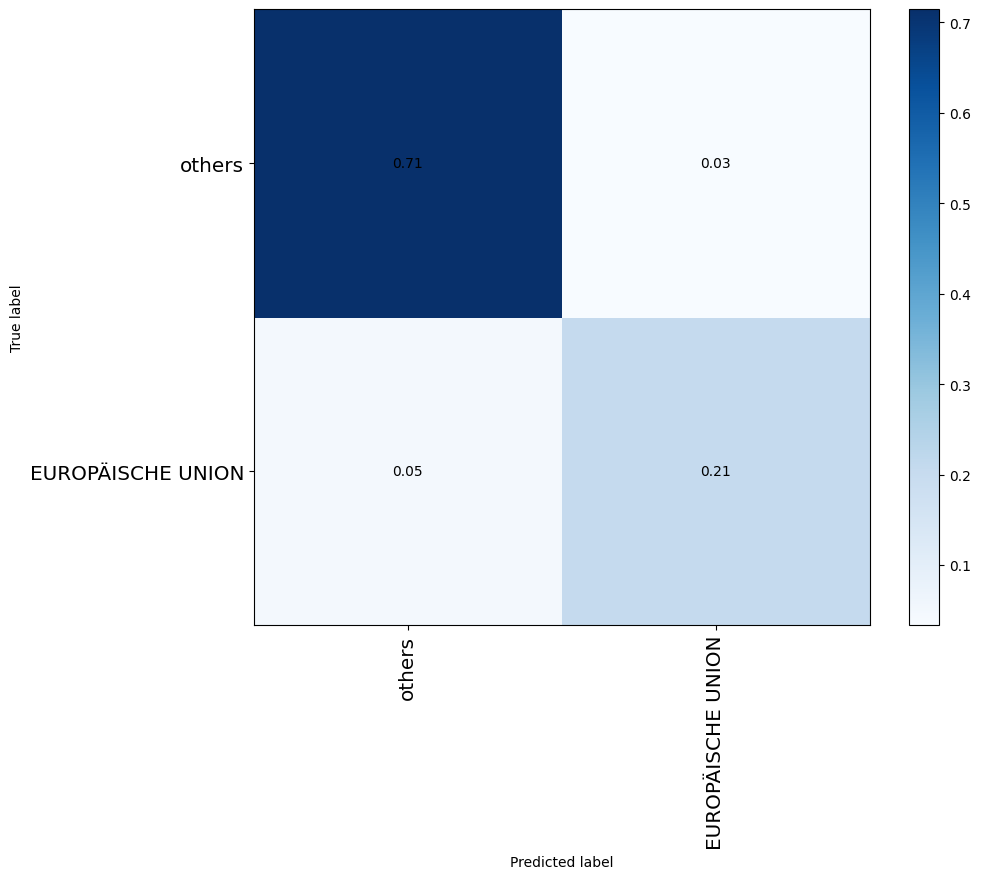

Set Population: 51985
Accuracy: 0.9621


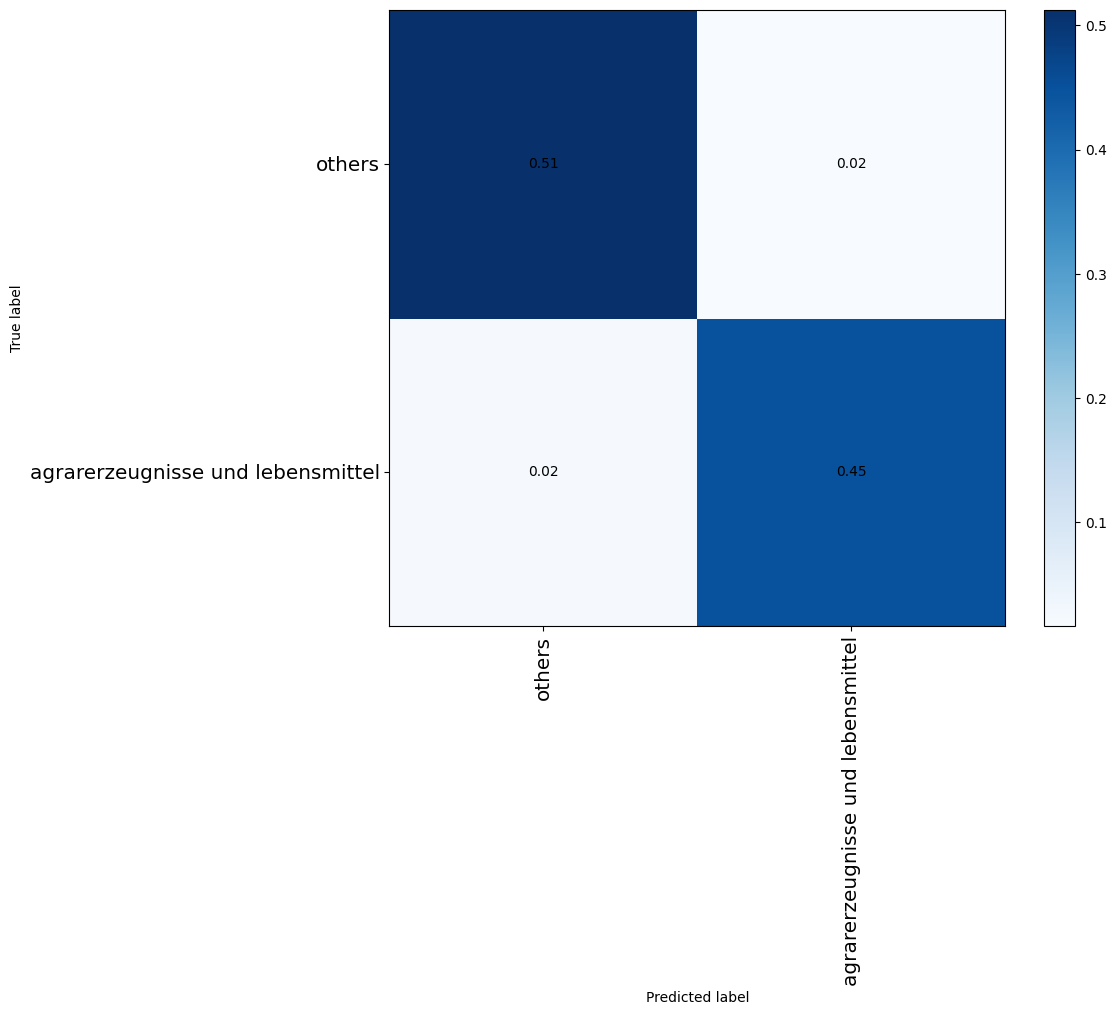

Set Population: 51985
Accuracy: 0.9651


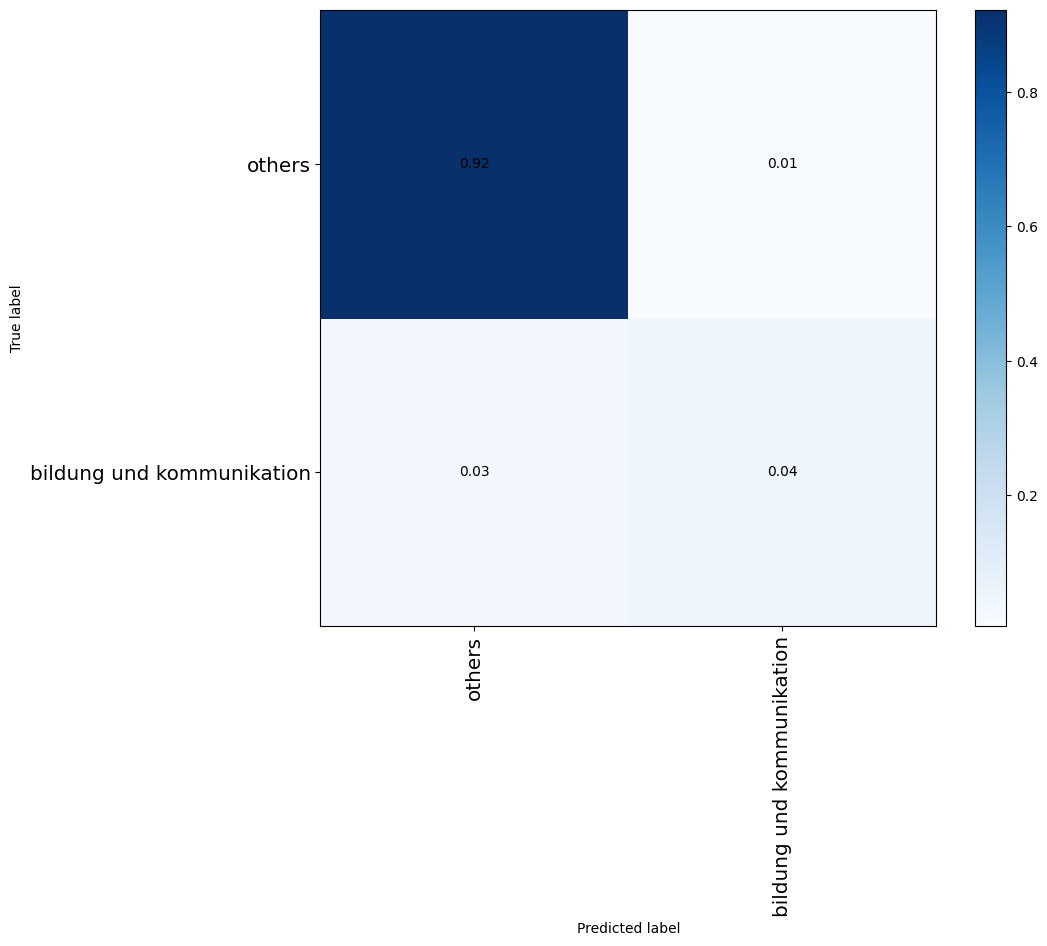

Set Population: 51985
Accuracy: 0.9921


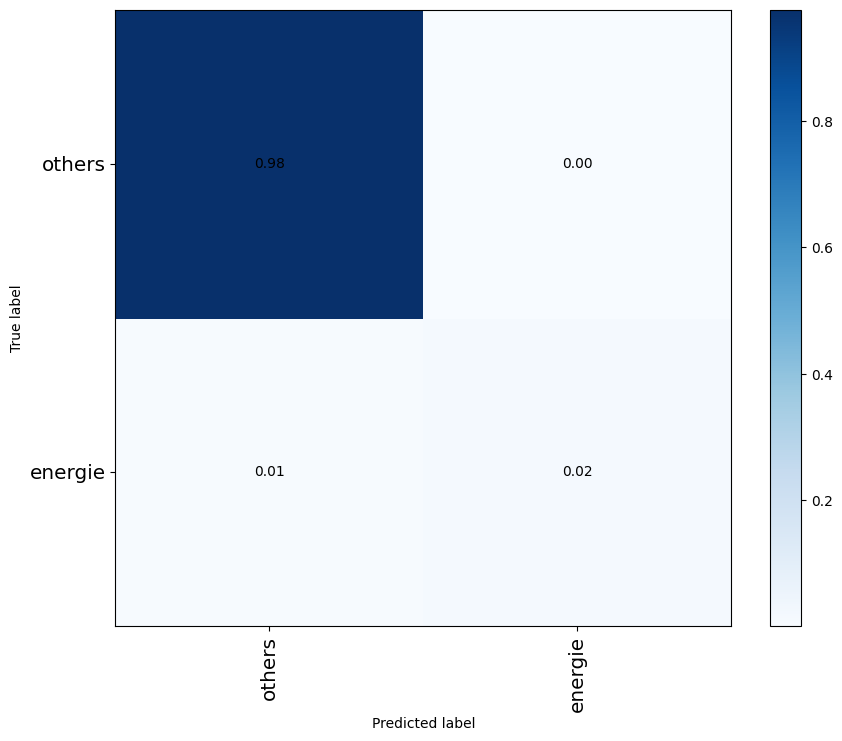

Set Population: 51985
Accuracy: 0.9627


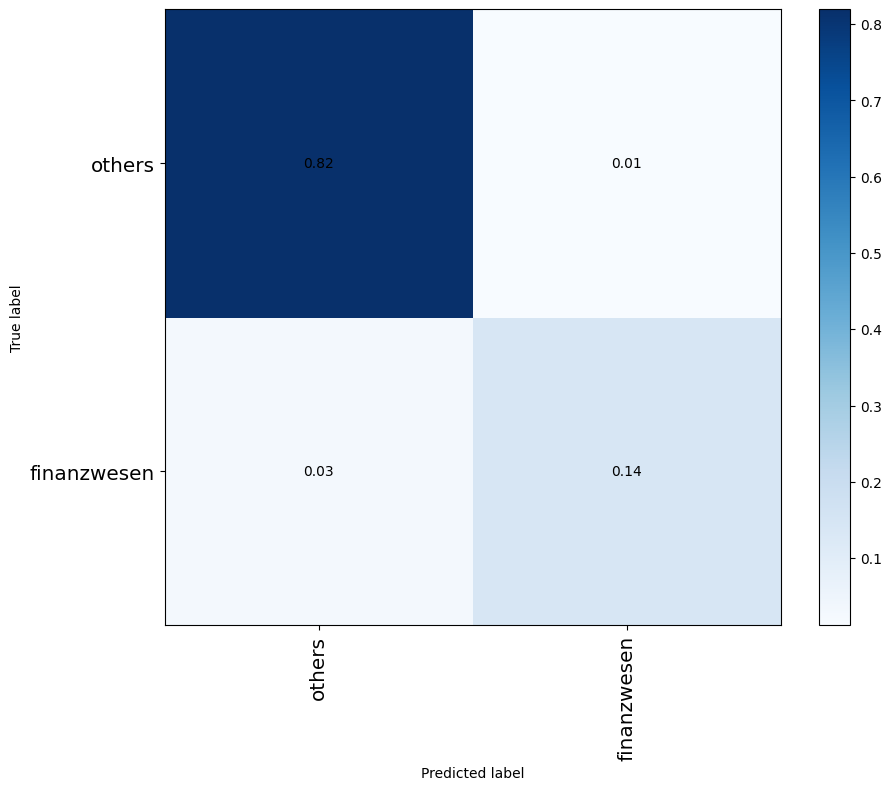

Set Population: 51985
Accuracy: 0.9412


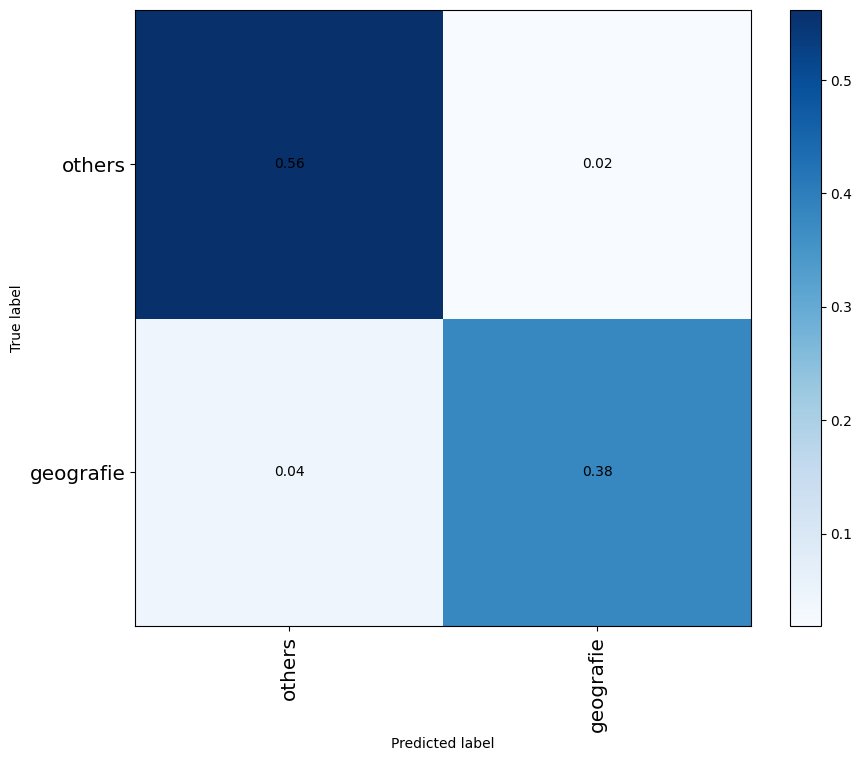

Set Population: 51985
Accuracy: 0.9332


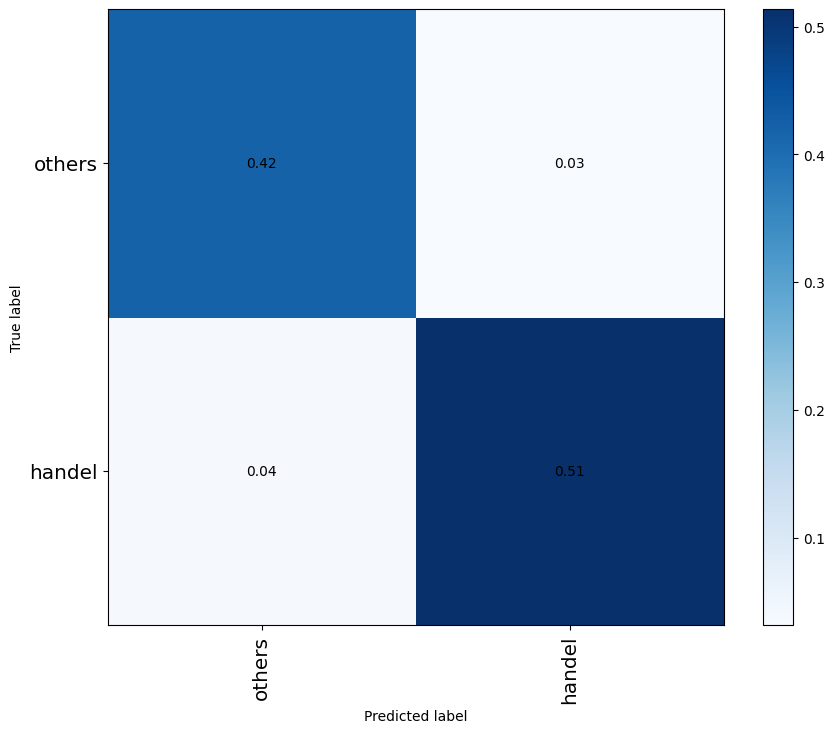

Set Population: 51985
Accuracy: 0.9668


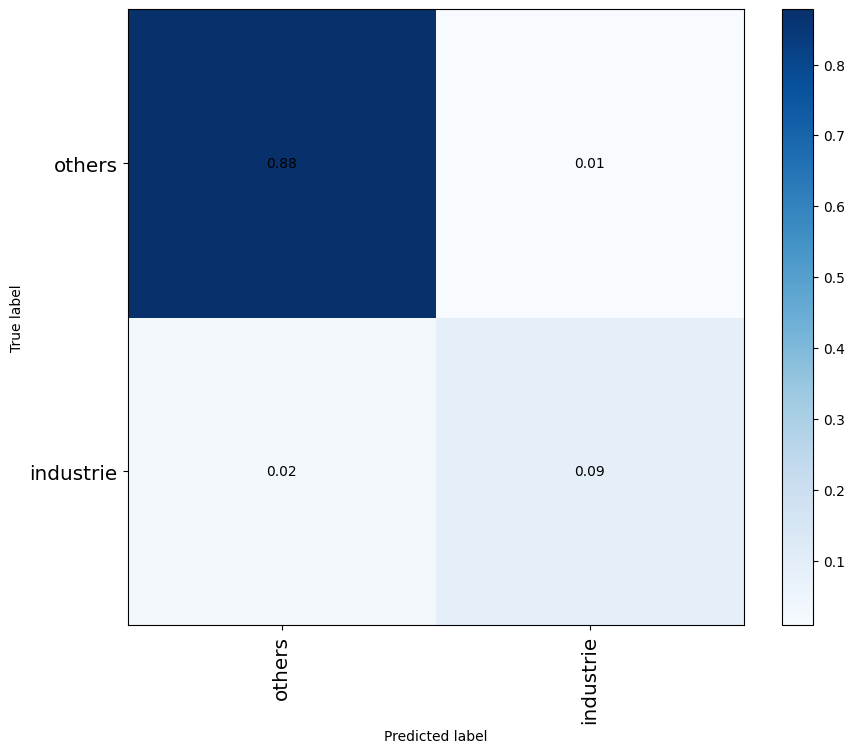

Set Population: 51985
Accuracy: 0.9400


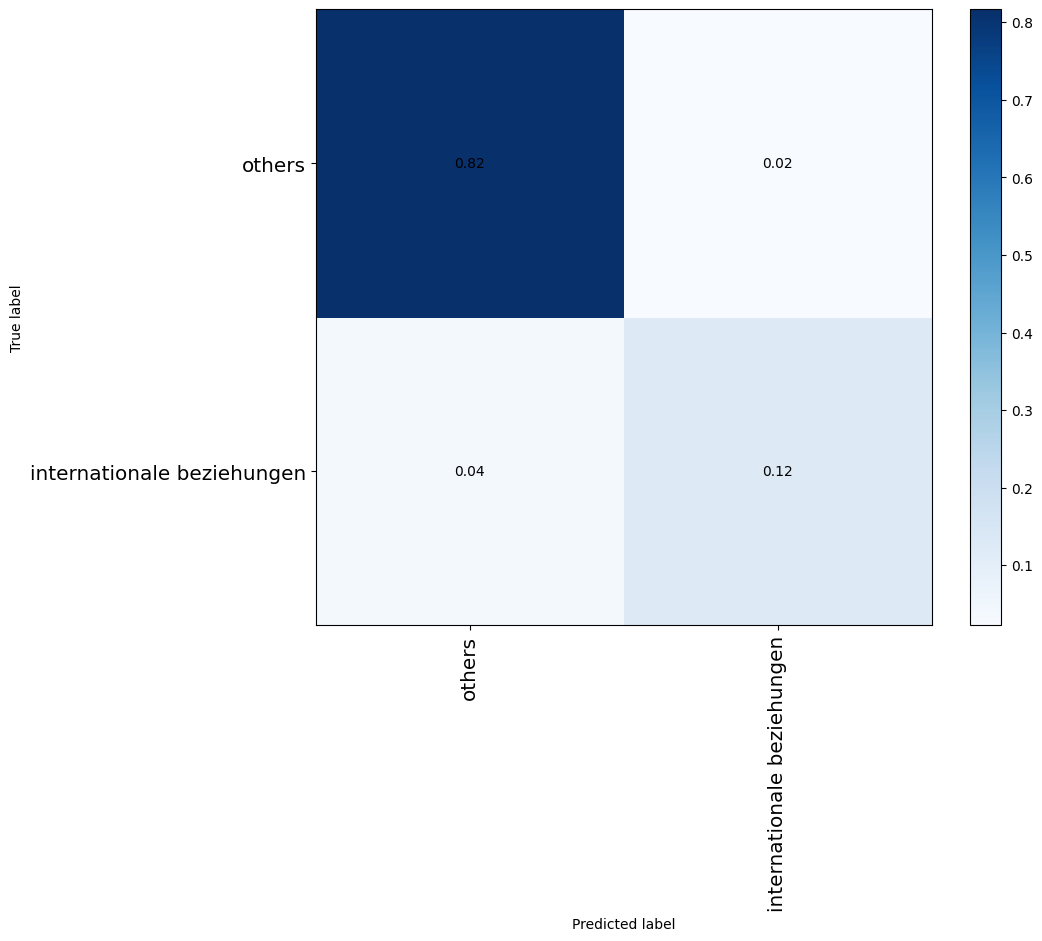

Set Population: 51985
Accuracy: 0.9907


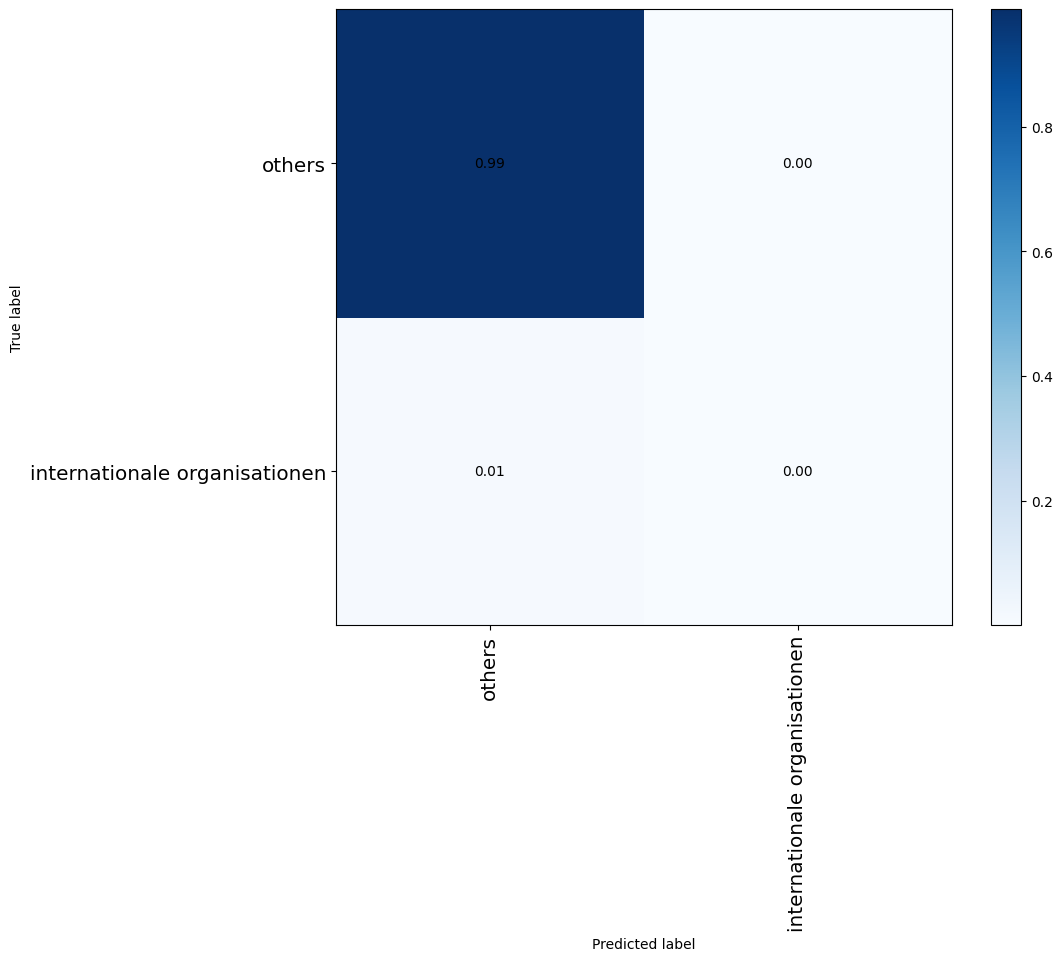

Set Population: 51985
Accuracy: 0.9409


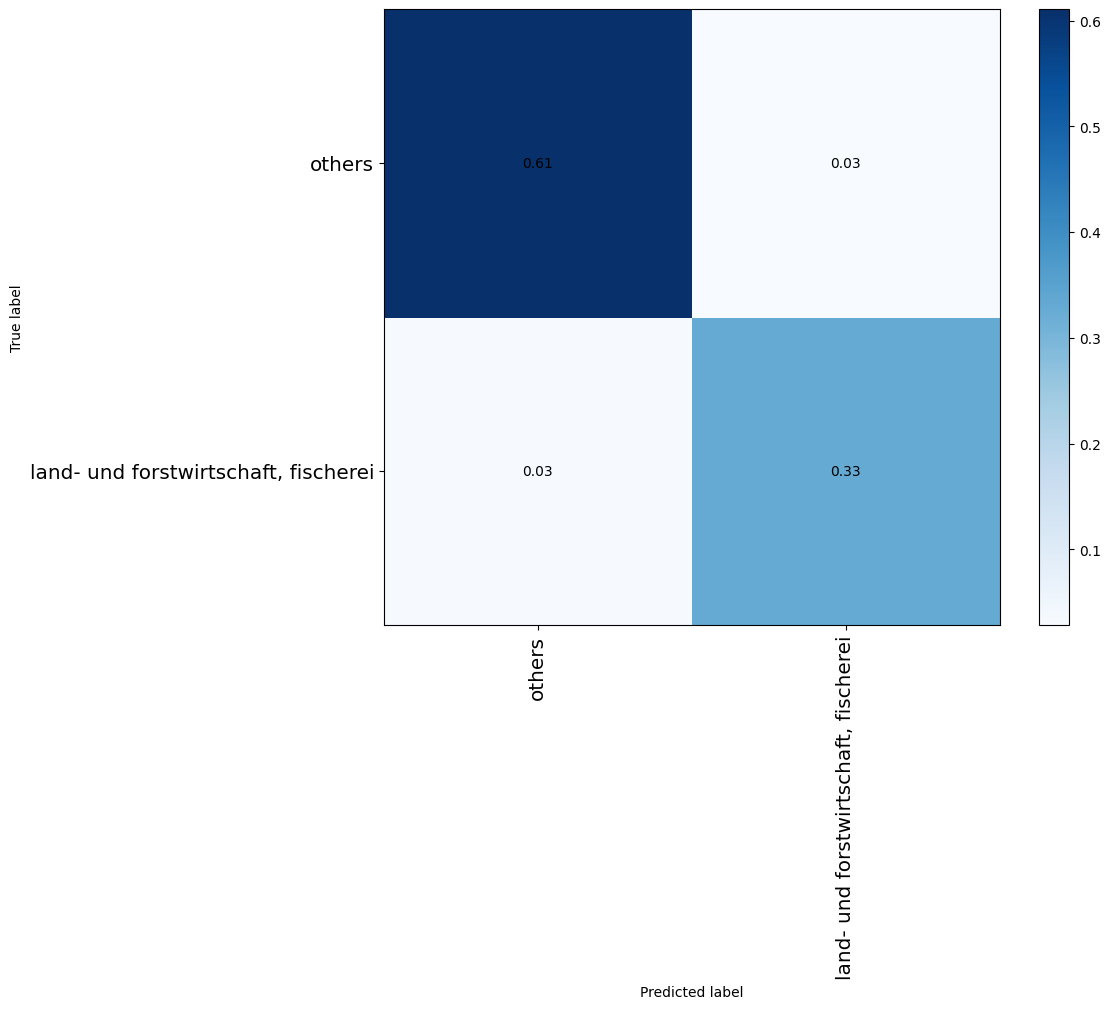

Set Population: 51985
Accuracy: 0.9618


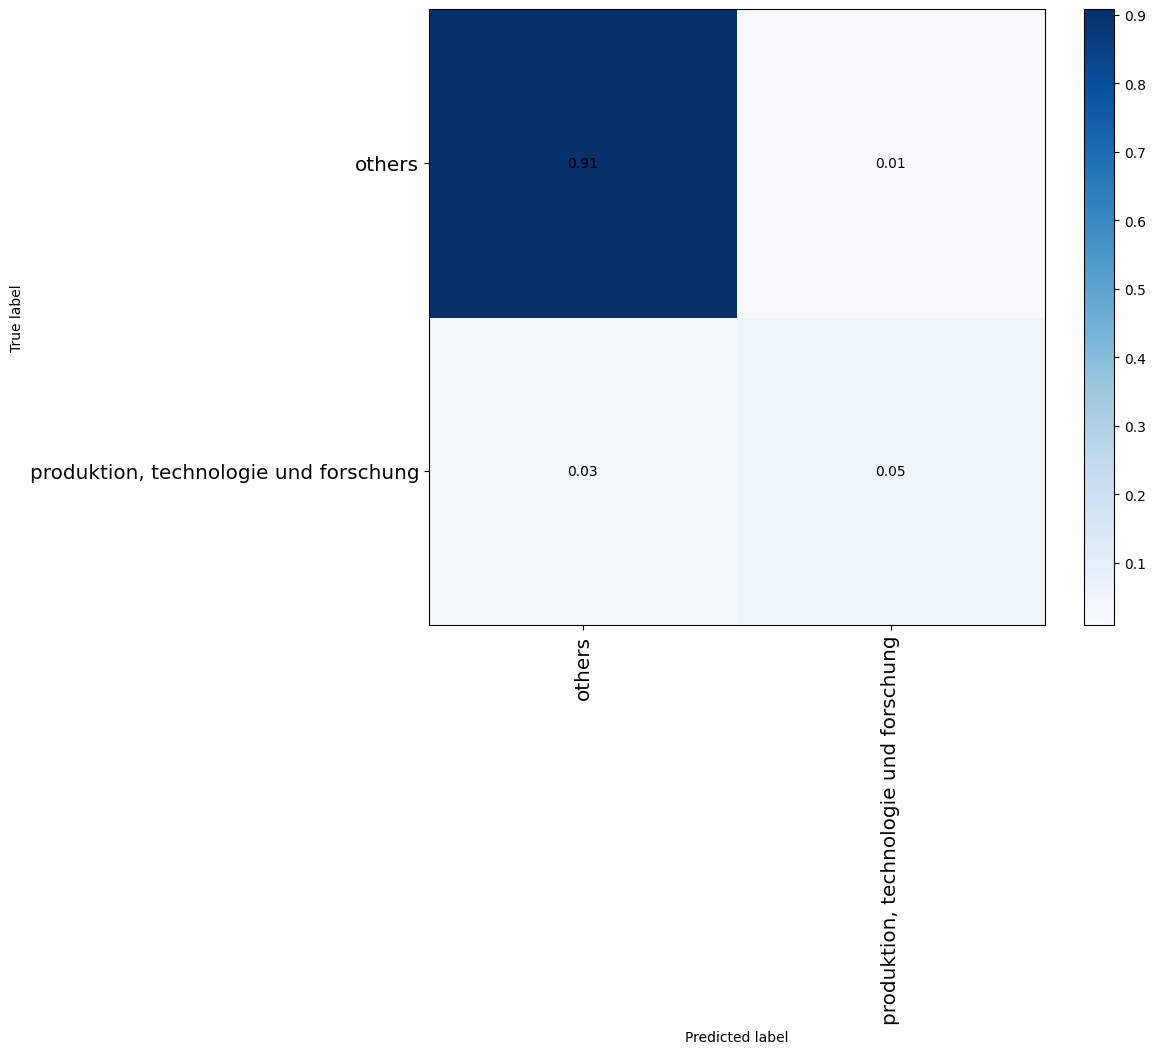

Set Population: 51985
Accuracy: 0.9704


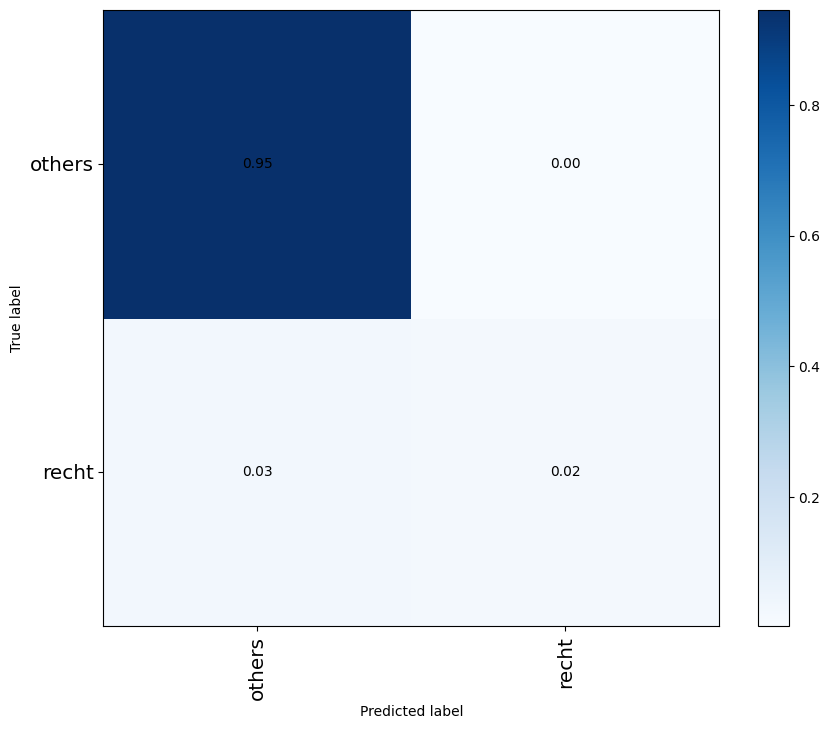

Set Population: 51985
Accuracy: 0.9535


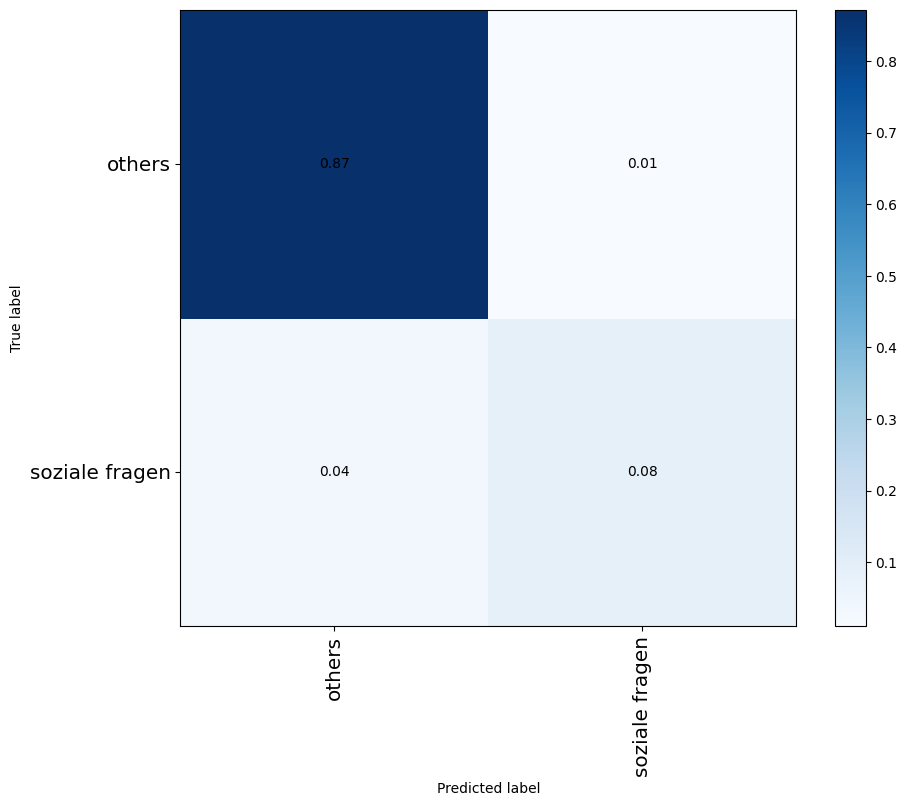

Set Population: 51985
Accuracy: 0.9752


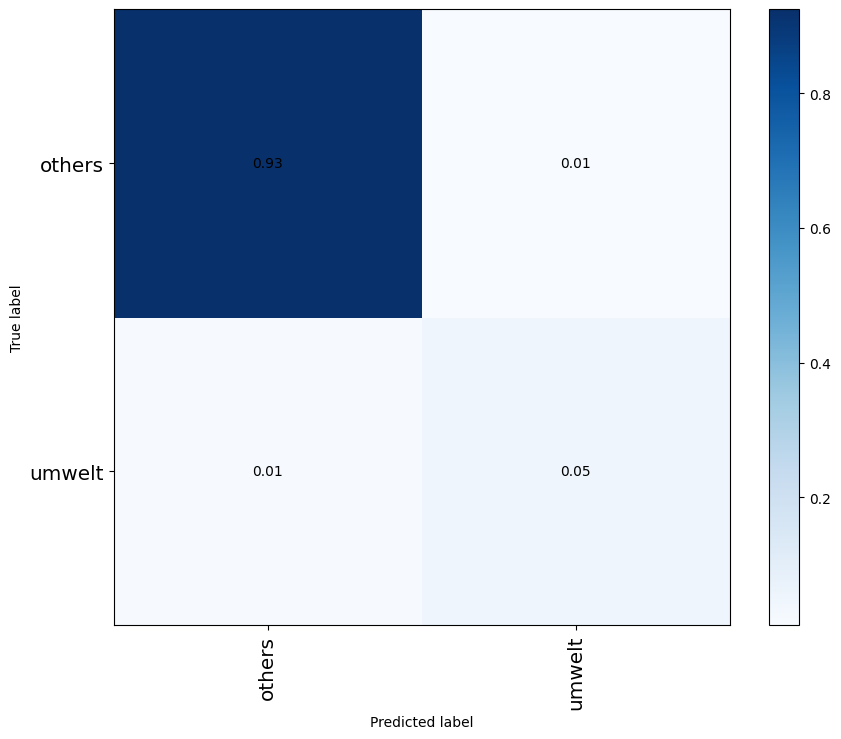

Set Population: 51985
Accuracy: 0.9699


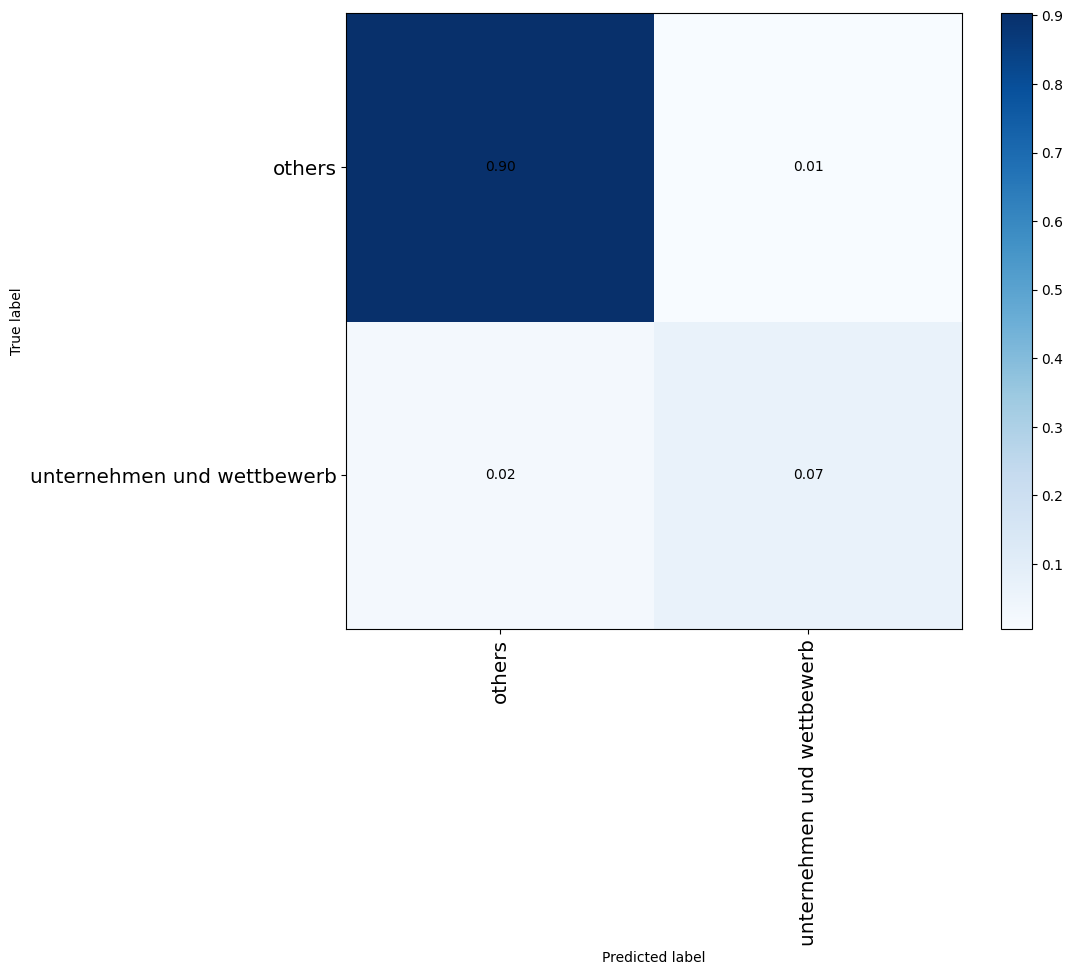

Set Population: 51985
Accuracy: 0.9852


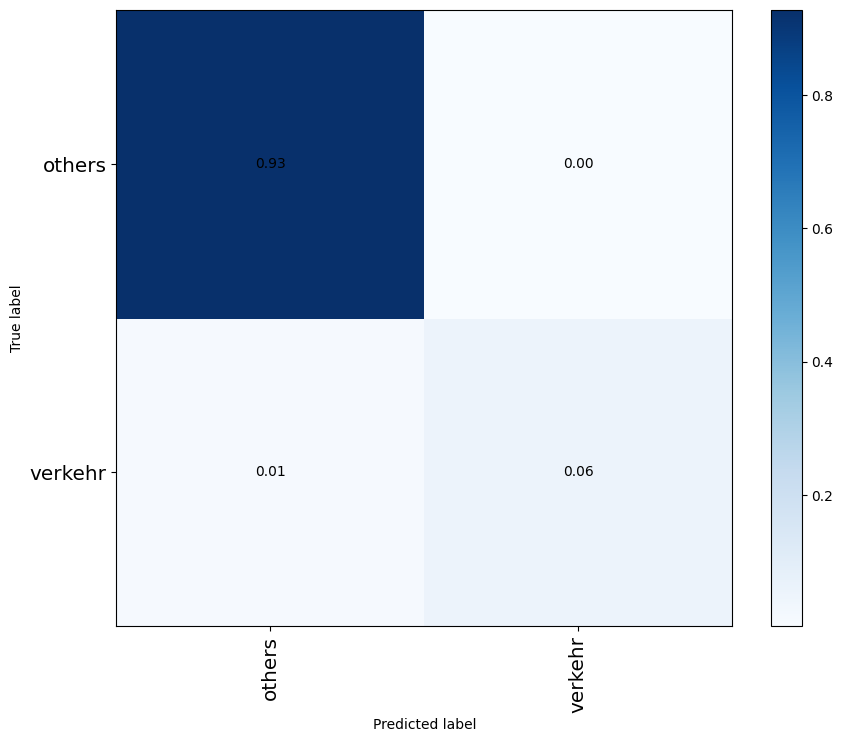

Set Population: 51985
Accuracy: 0.9512


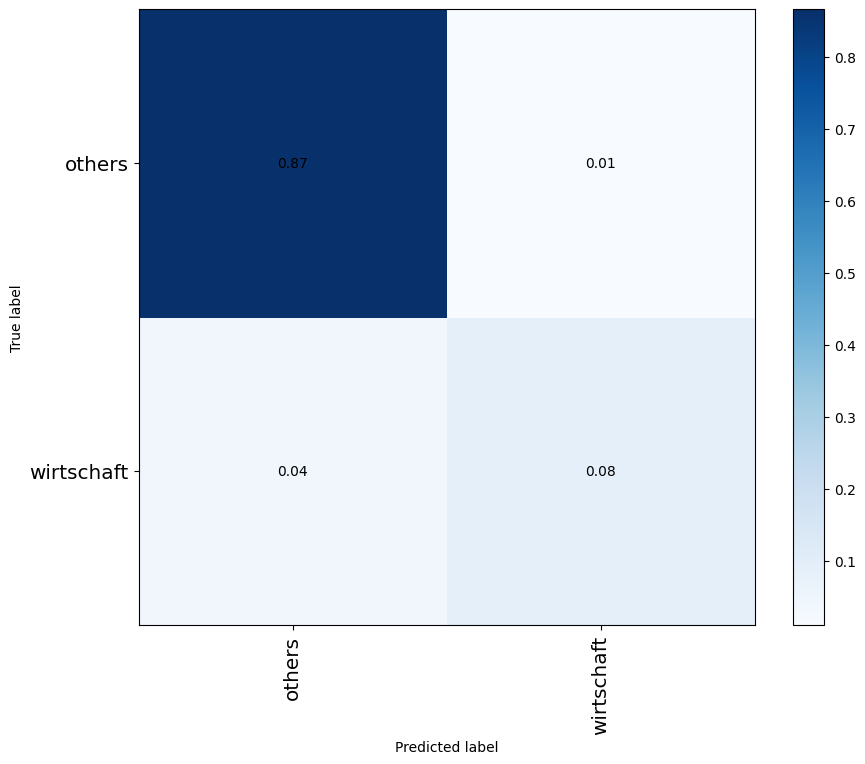

Set Population: 51985
Accuracy: 0.9898


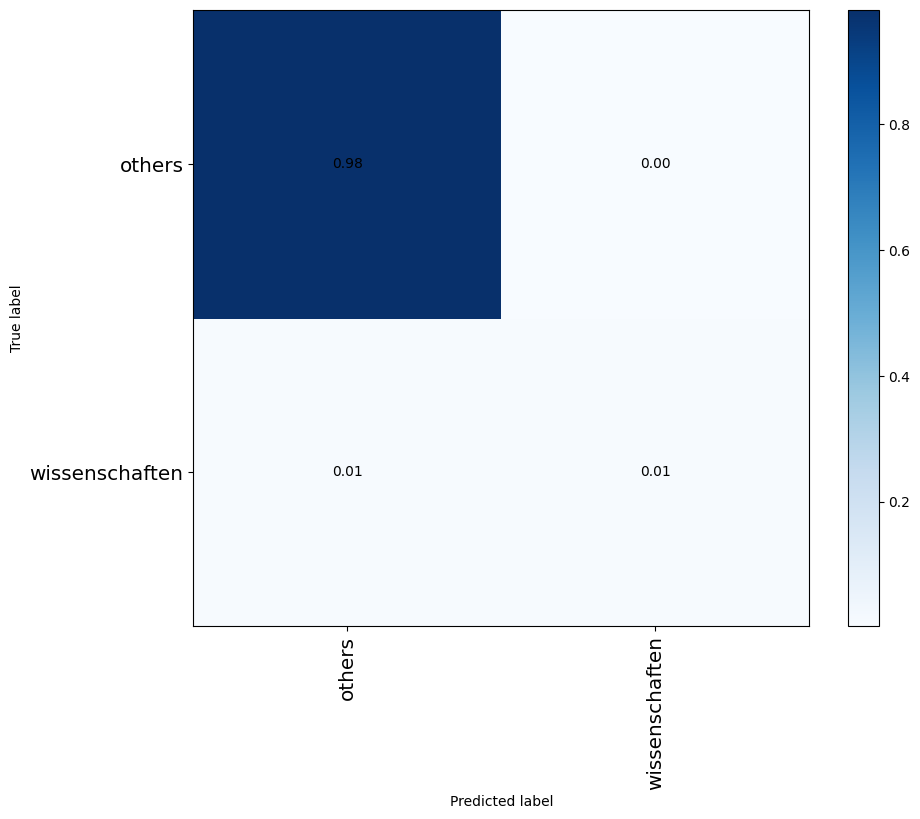

                                       precision    recall  f1-score   support

                    EUROPÄISCHE UNION       0.86      0.82      0.84     13092
    agrarerzeugnisse und lebensmittel       0.96      0.95      0.96     24468
            bildung und kommunikation       0.87      0.60      0.71      3697
                              energie       0.91      0.72      0.80      1169
                          finanzwesen       0.93      0.85      0.89      8791
                            geografie       0.95      0.90      0.93     21812
                               handel       0.94      0.94      0.94     28544
                            industrie       0.91      0.79      0.84      5897
           internationale beziehungen       0.85      0.76      0.80      8379
        internationale organisationen       0.87      0.18      0.30       570
 land- und forstwirtschaft, fischerei       0.92      0.91      0.92     18762
produktion, technologie und forschung       0.86   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [46]:
# see https://towardsdatascience.com/evaluating-multi-label-classifiers-a31be83da6ea for interpretation

from fhnw.nlp.utils.ploting import report_classification_results

report_classification_results(params, labels_train + labels_val, labels_train_pred + labels_val_pred)

Set Population: 13008
Accuracy: 0.8905


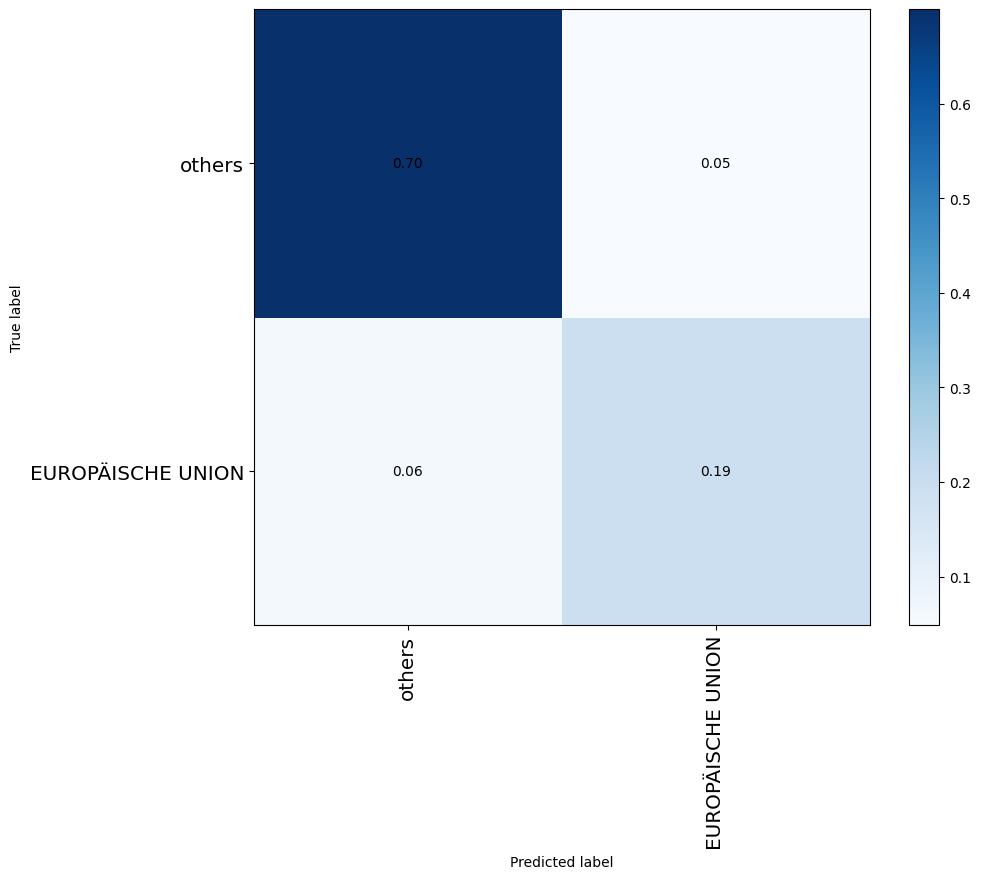

Set Population: 13008
Accuracy: 0.9470


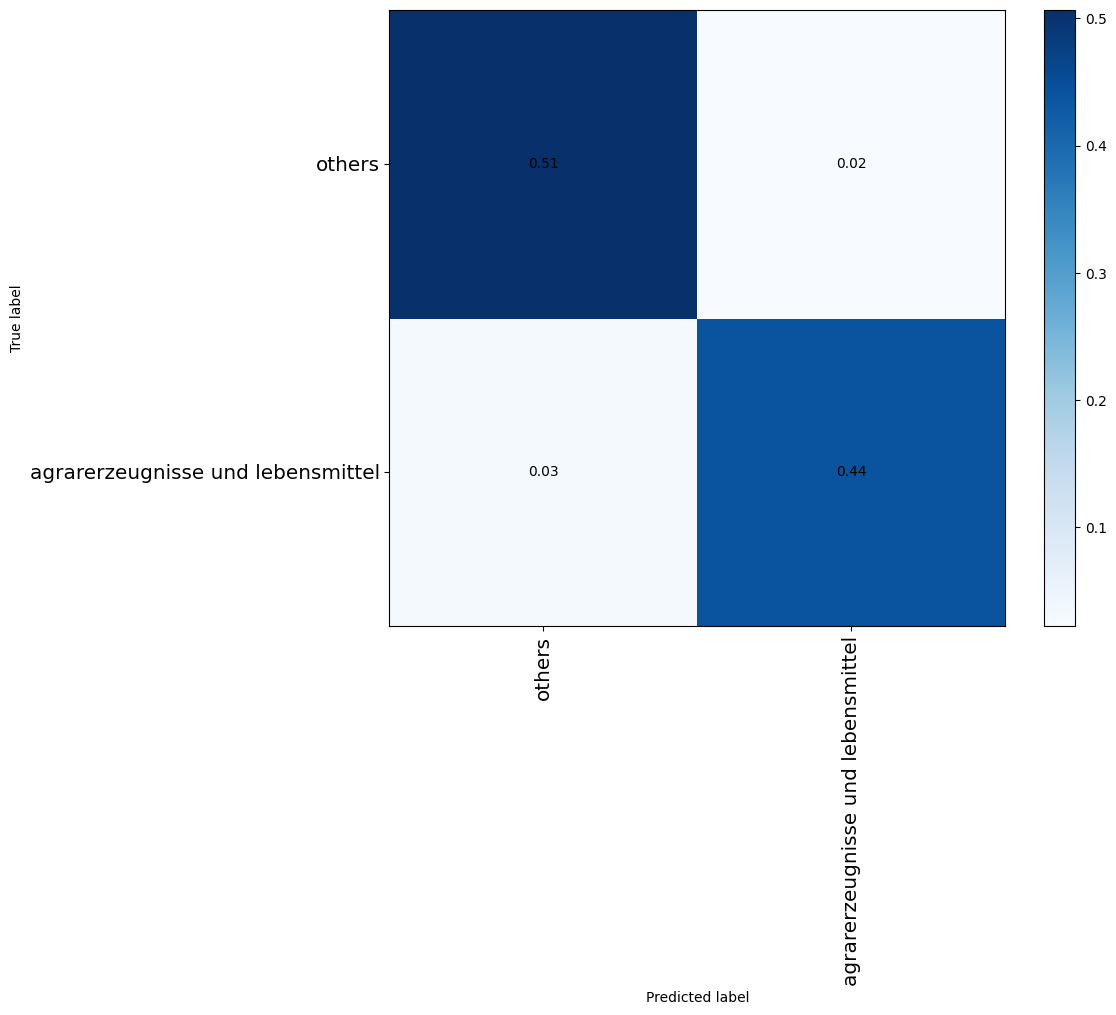

Set Population: 13008
Accuracy: 0.9547


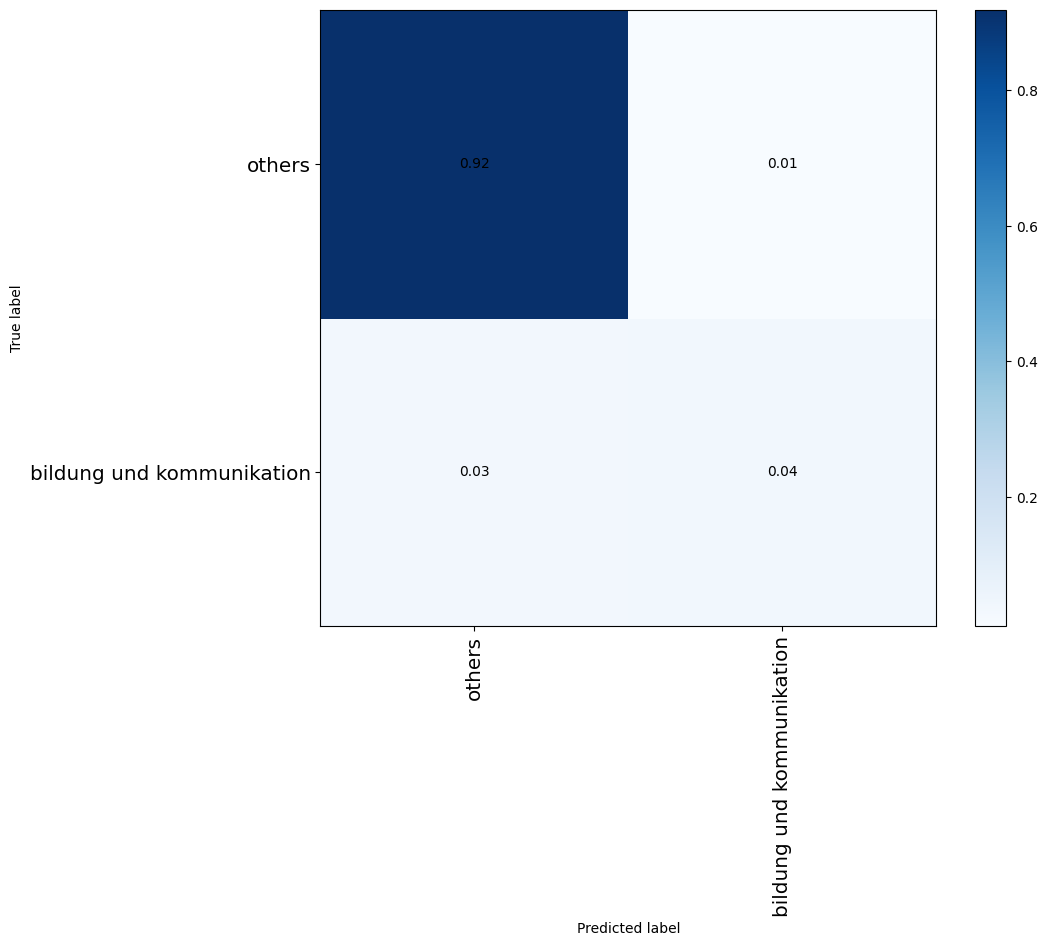

Set Population: 13008
Accuracy: 0.9908


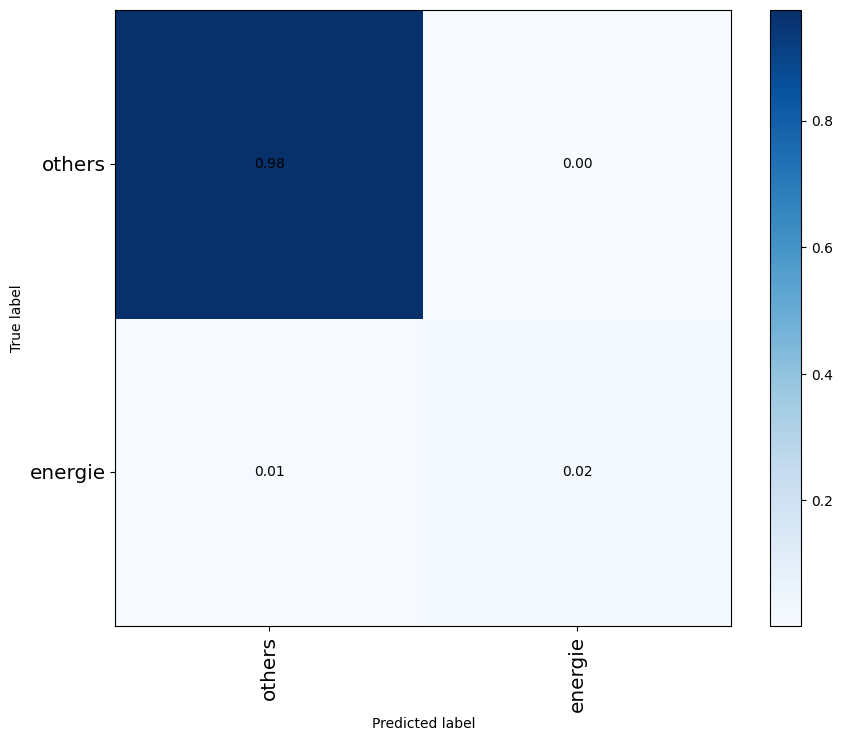

Set Population: 13008
Accuracy: 0.9510


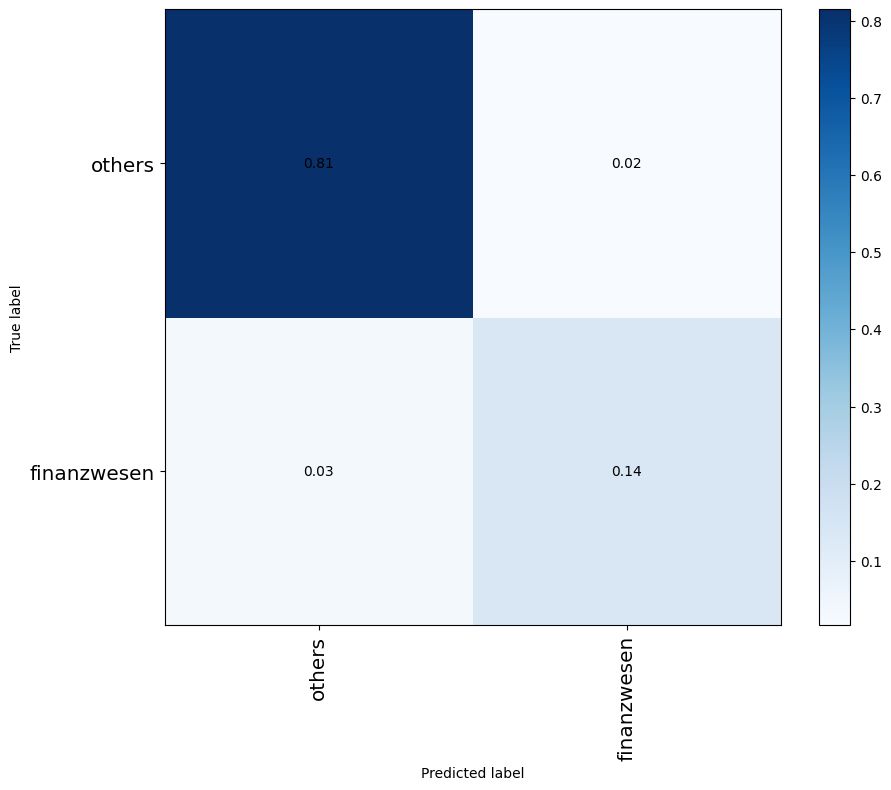

Set Population: 13008
Accuracy: 0.9234


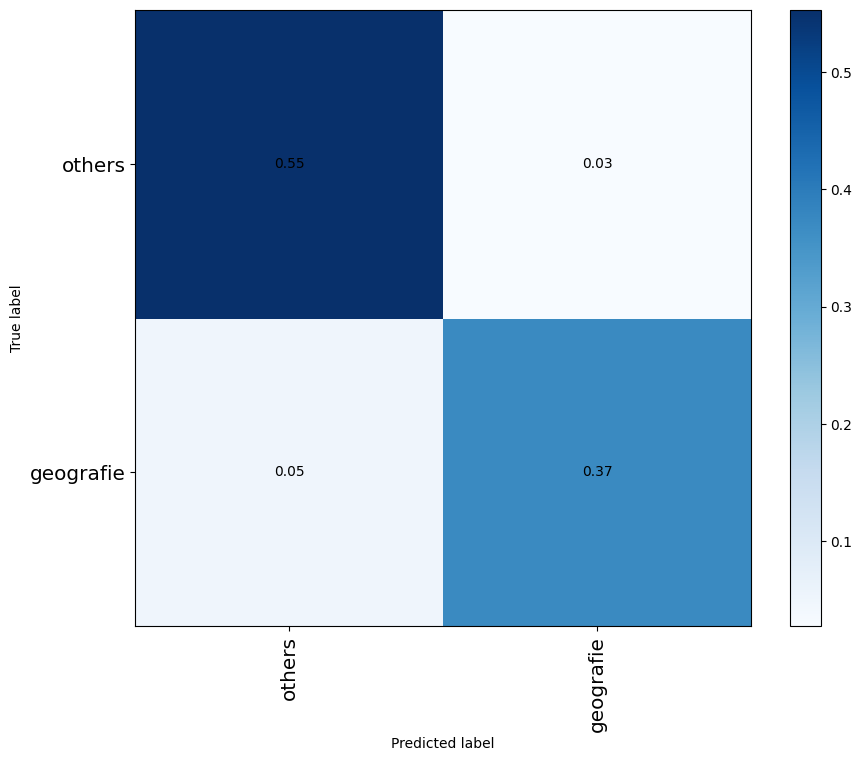

Set Population: 13008
Accuracy: 0.9104


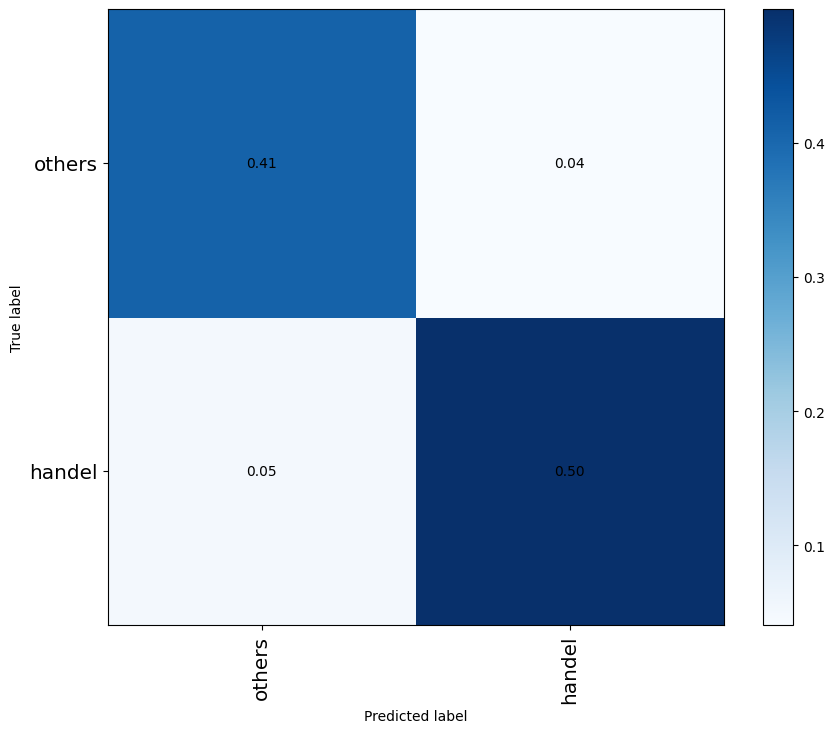

Set Population: 13008
Accuracy: 0.9550


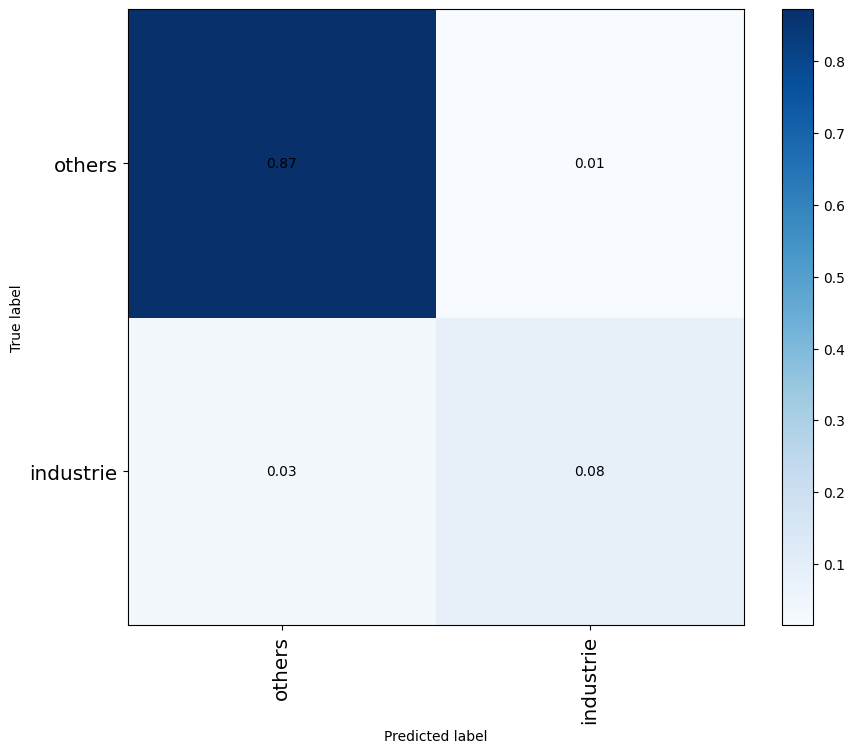

Set Population: 13008
Accuracy: 0.9212


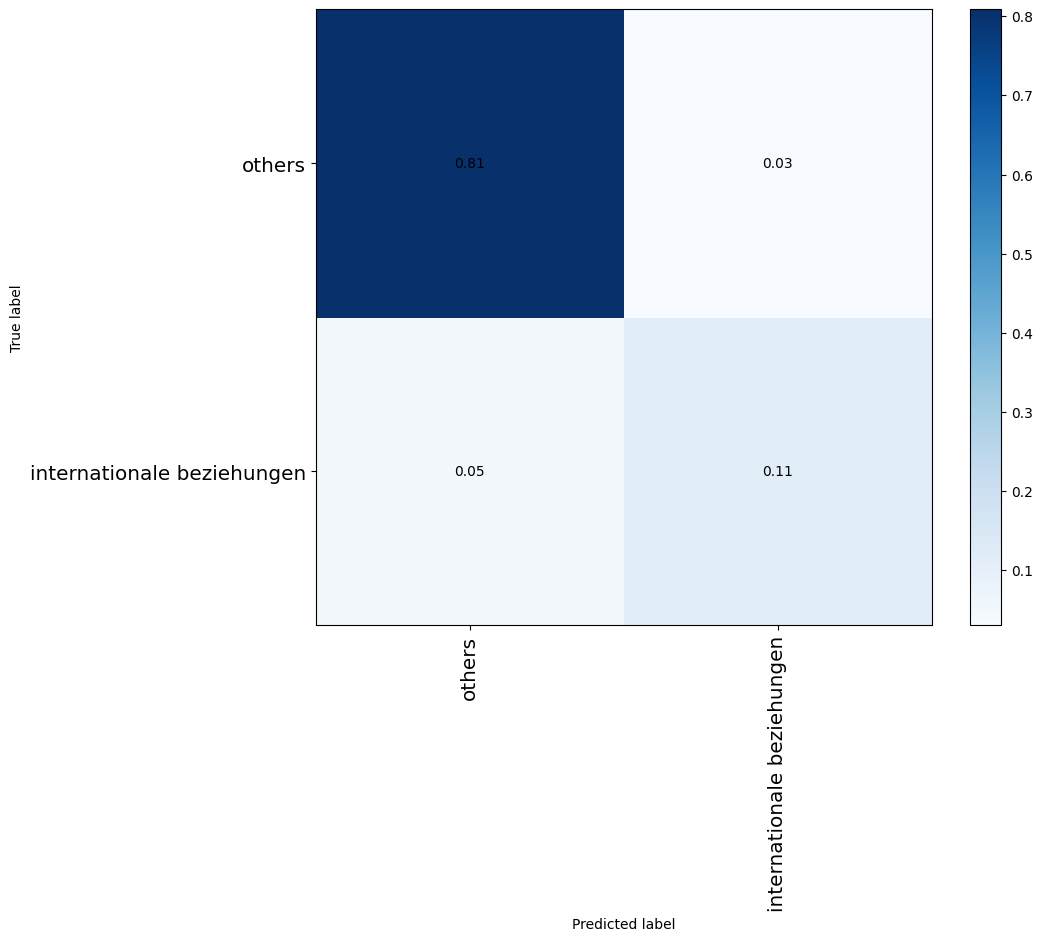

Set Population: 13008
Accuracy: 0.9897


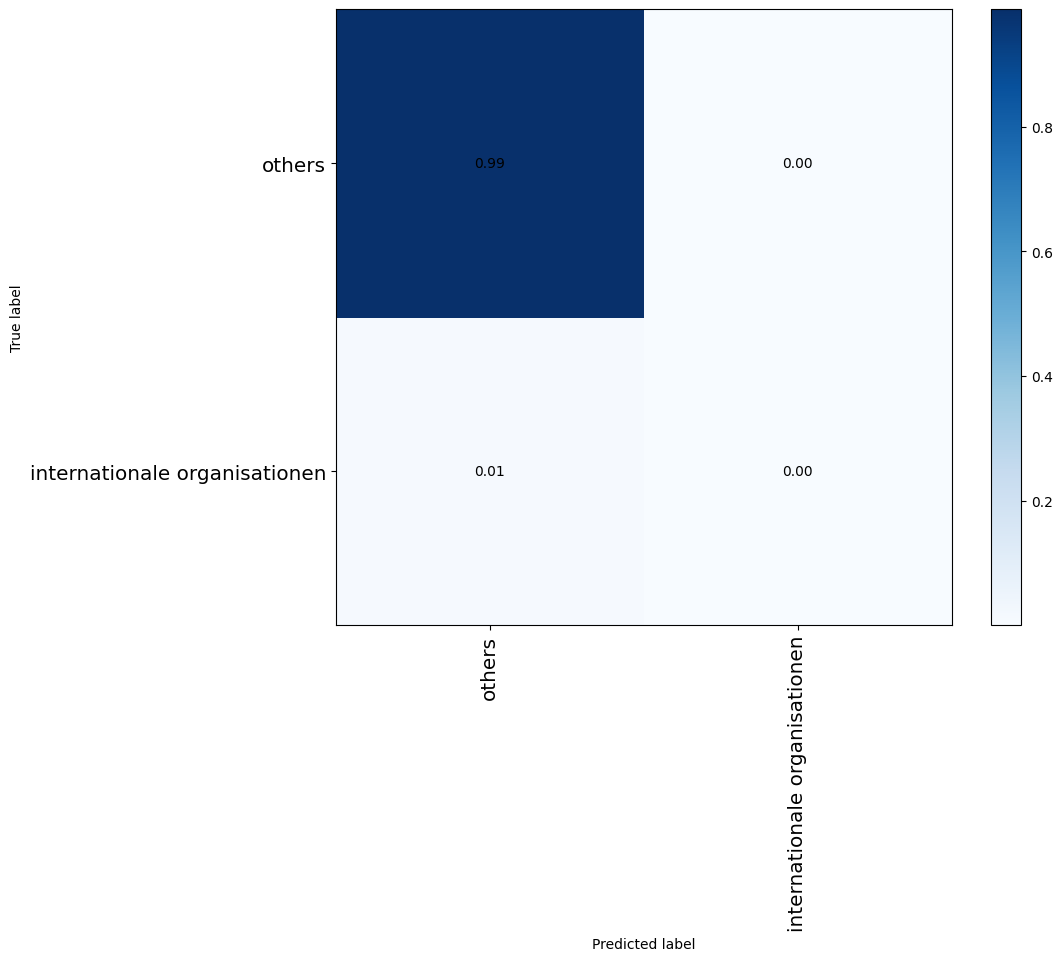

Set Population: 13008
Accuracy: 0.9258


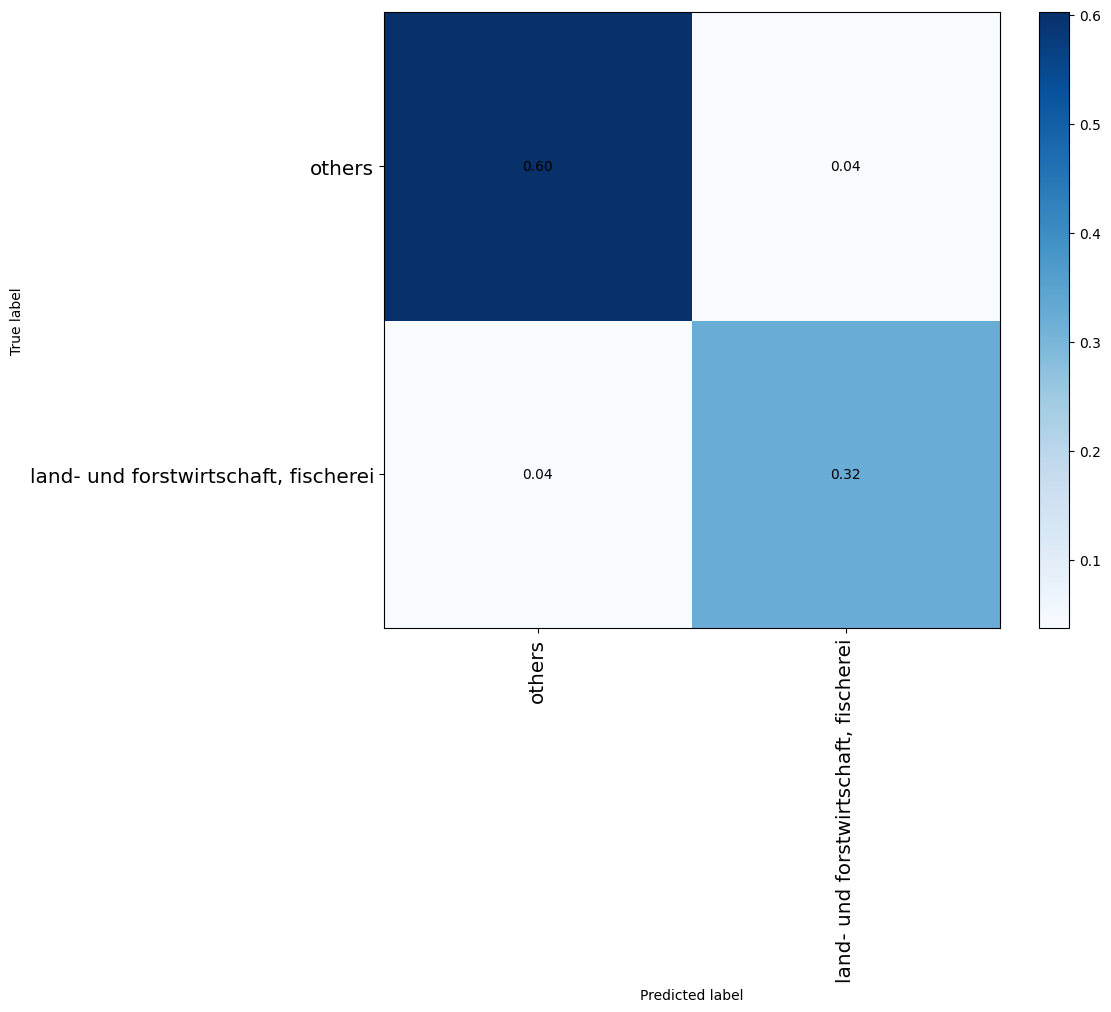

Set Population: 13008
Accuracy: 0.9496


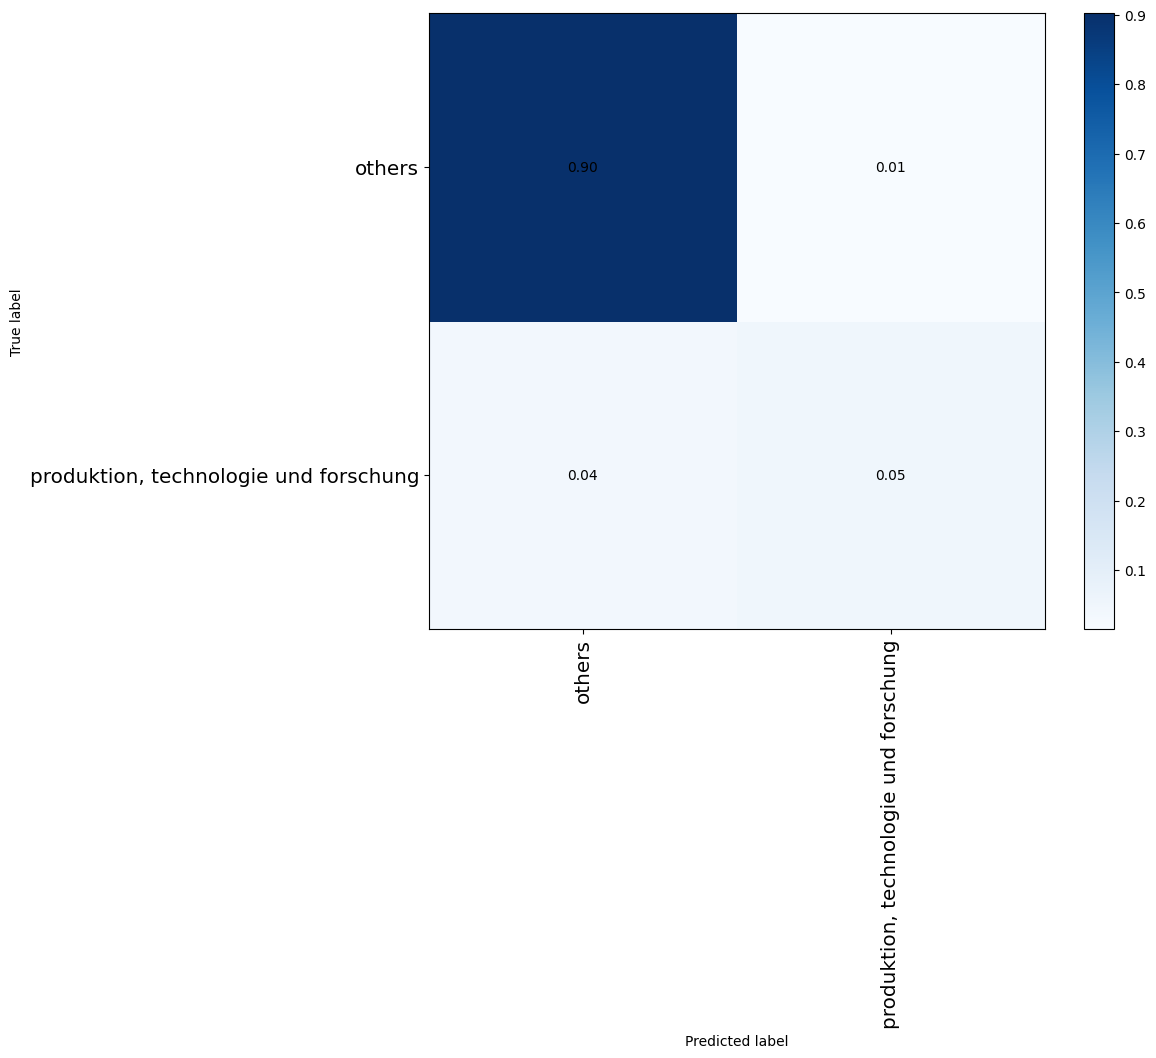

Set Population: 13008
Accuracy: 0.9665


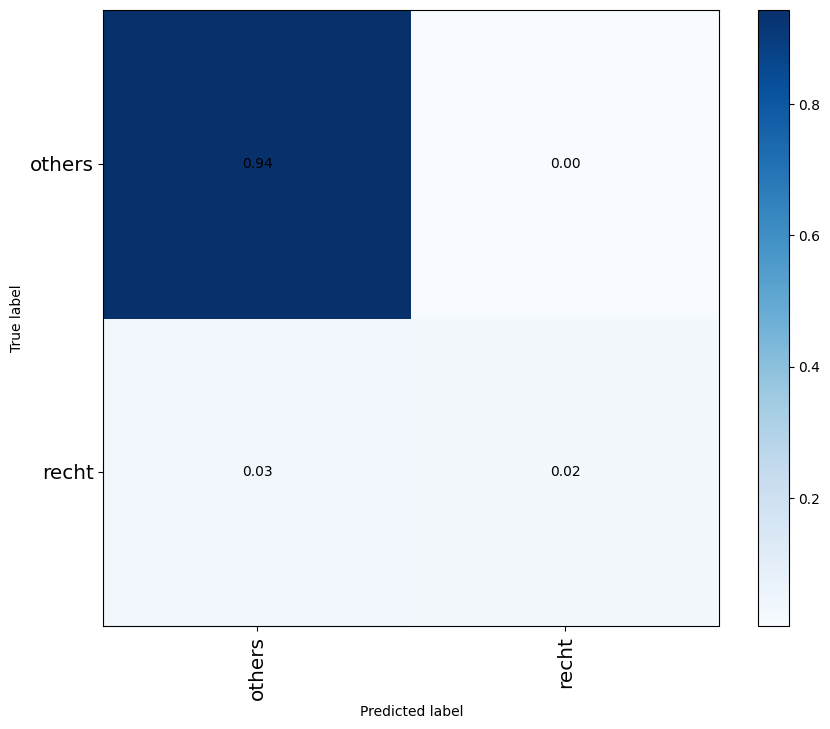

Set Population: 13008
Accuracy: 0.9455


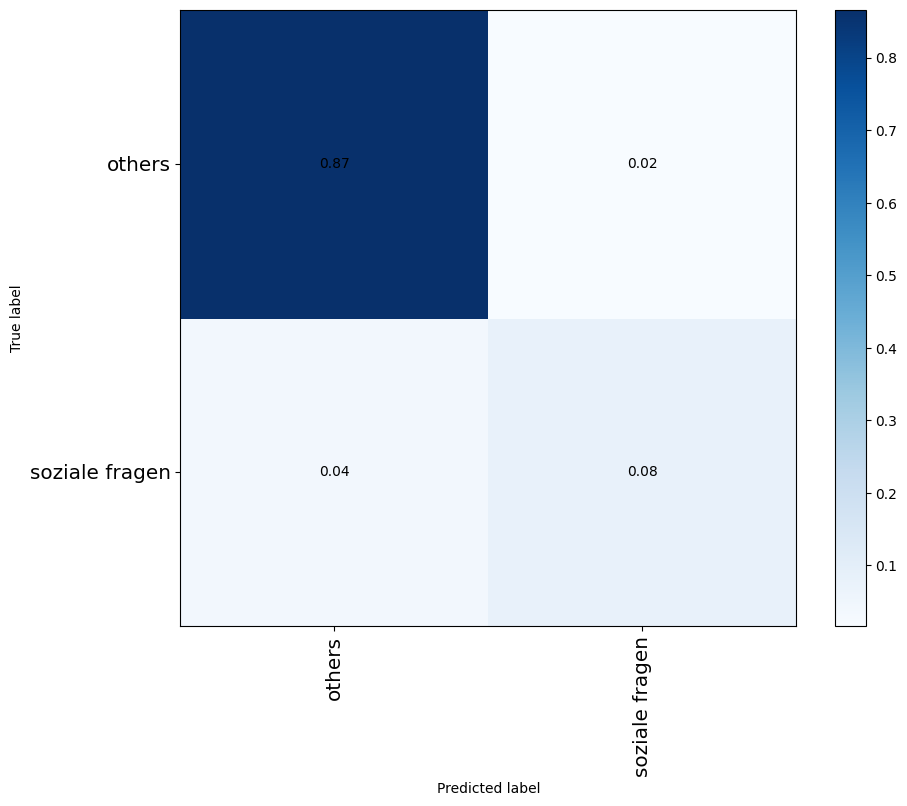

Set Population: 13008
Accuracy: 0.9689


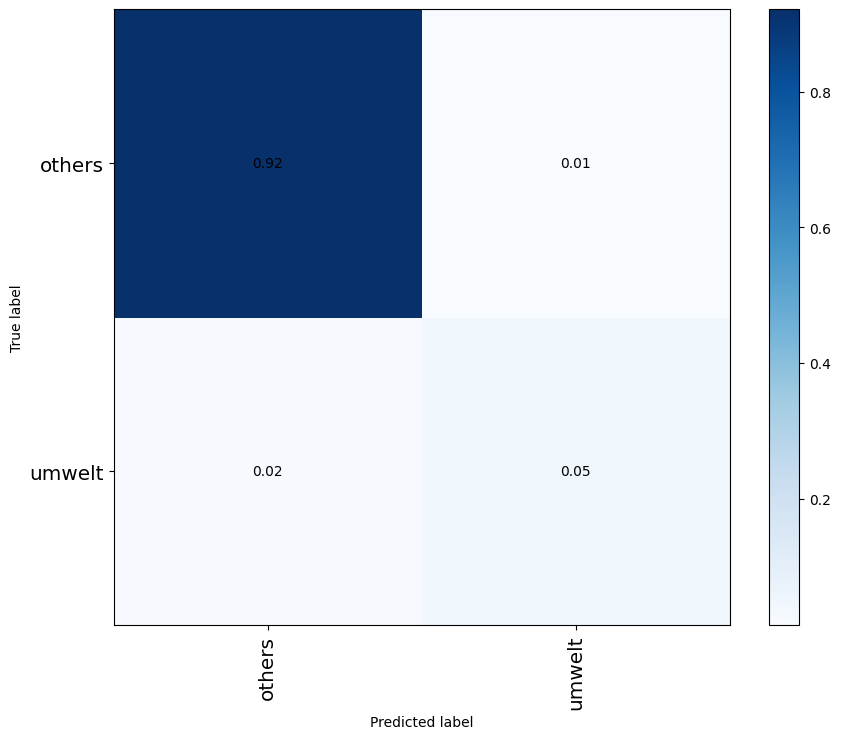

Set Population: 13008
Accuracy: 0.9605


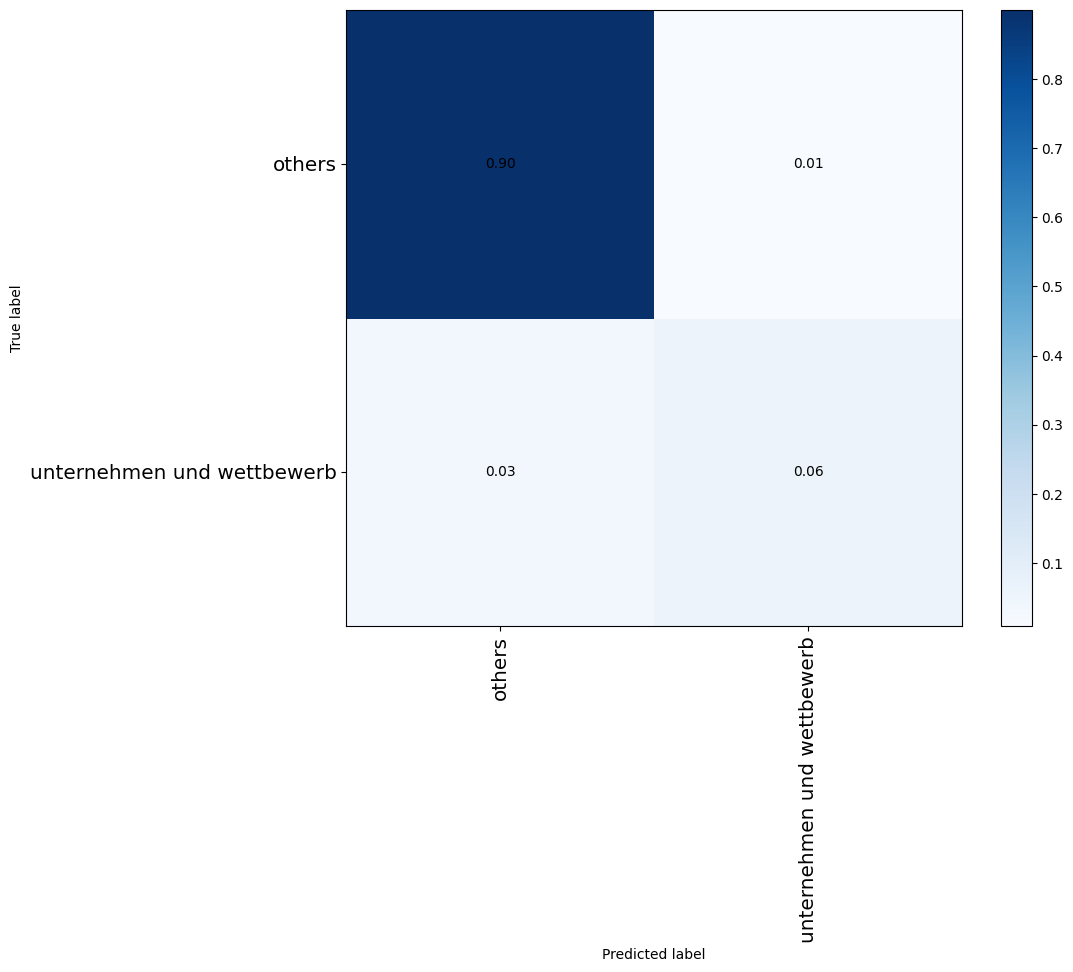

Set Population: 13008
Accuracy: 0.9821


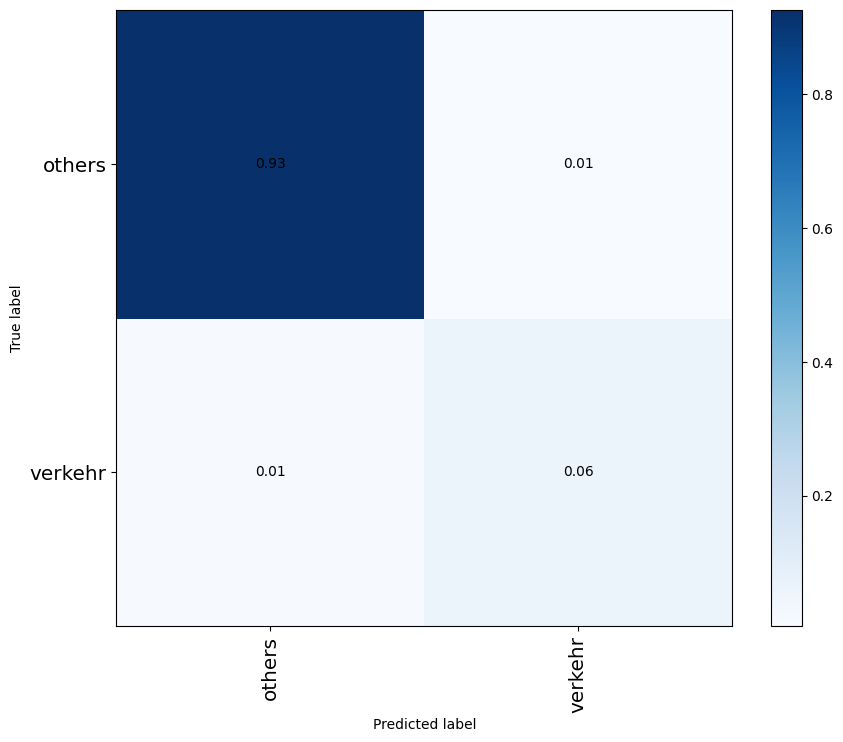

Set Population: 13008
Accuracy: 0.9400


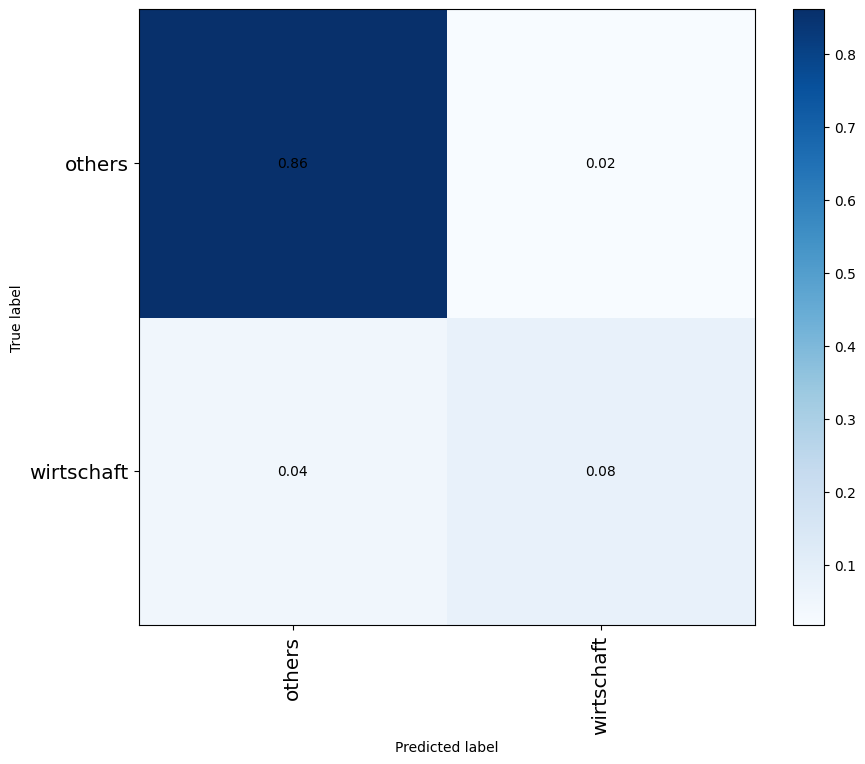

Set Population: 13008
Accuracy: 0.9880


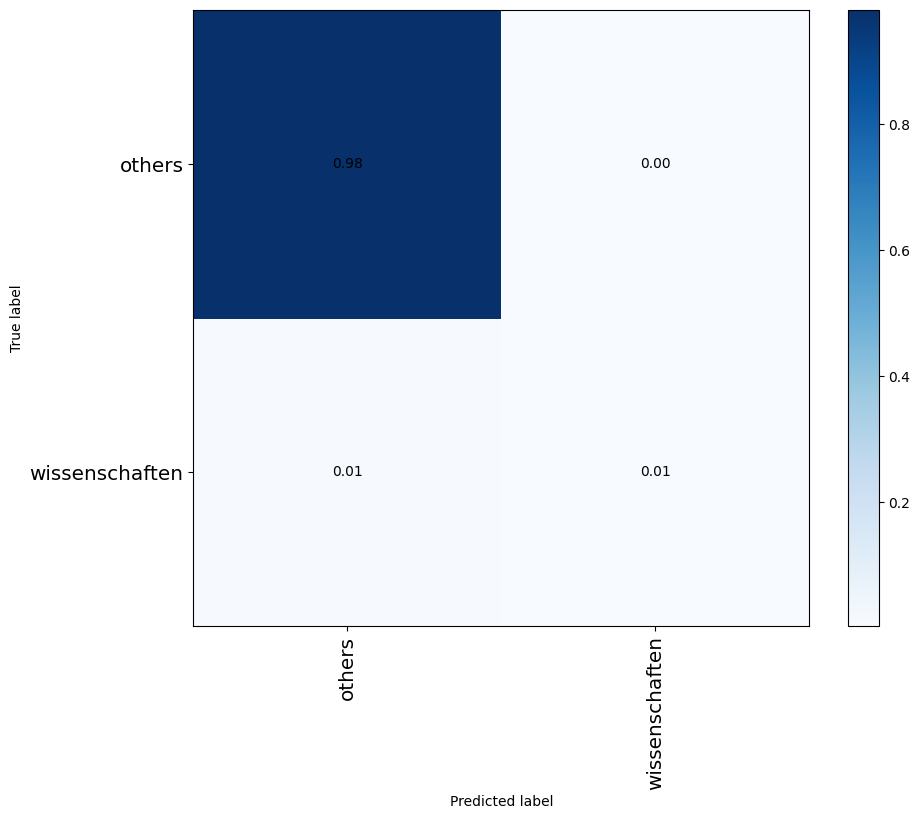

                                       precision    recall  f1-score   support

                    EUROPÄISCHE UNION       0.80      0.76      0.78      3273
    agrarerzeugnisse und lebensmittel       0.95      0.94      0.94      6117
            bildung und kommunikation       0.78      0.51      0.62       925
                              energie       0.87      0.69      0.77       292
                          finanzwesen       0.89      0.81      0.85      2197
                            geografie       0.93      0.88      0.91      5453
                               handel       0.92      0.91      0.92      7137
                            industrie       0.85      0.73      0.79      1474
           internationale beziehungen       0.79      0.70      0.74      2095
        internationale organisationen       0.67      0.11      0.19       142
 land- und forstwirtschaft, fischerei       0.90      0.90      0.90      4690
produktion, technologie und forschung       0.76   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [47]:
report_classification_results(params, labels_test, labels_test_pred)